In [2]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

# 1. 패키지로드 & 한글설정 & 경고메세지 ignore

In [3]:
# 패키지 import
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 시각화의 선명도를 높임
%config InlineBackend.figure_format = "retina"
# from IPython.display import set_matplotlib_formats
# set_matplotlib_formats('retina')

# 다른 폰트를 기본으로 하려면
# from matplotlib.font_manager import FontProperties, fontManager
# font_path = 'data/font/온글잎밑미.ttf'
# #font_path = "c:/Windows/Fonts/H2PORM.TTF"
# fontproperties = FontProperties(fname=font_path, size=30)
# fontManager.addfont(file_path) # windows폴더에 있지 않는 ttf파일일 경우 
# font_name = fontproperties.get_name()

# 한글설정 및 미적속성 설정
sns.set(style='white',
       context='notebook',
       palette='Dark2',
       rc={'figure.figsize': (12,3),
           'font.family':'Malgun Gothic',
           # font.family':font_name,
           #'font.size':20,
           'axes.unicode_minus':False})

# warning(경고) 안보이게
import warnings
# warnings.filterwarnings(action='ignore') # 경고 메세지 안보이게
# warnings.filterwarnings(action='default') # 경고 메세지 보이게

# 2. 데이터 다운받아, 서울과 부산데이터만 df변수에 읽어온다

In [4]:
%ls "c:/ai/downloads/shareData/상가정보/"

 C 드라이브의 볼륨에는 이름이 없습니다.
 볼륨 일련 번호: E67D-C334

 c:\ai\downloads\shareData\상가정보 디렉터리

2026-07-24  오전 11:49    <DIR>          .
2026-07-14  오후 05:39    <DIR>          ..
2025-11-03  오전 12:45             1,011 [필독]파일열람방법.txt
2026-04-27  오전 11:10        84,329,596 소상공인시장진흥공단_상가(상권)정보_부산_202603.csv
2026-04-27  오전 11:10       292,646,735 소상공인시장진흥공단_상가(상권)정보_서울_202603.csv
2026-04-27  오전 11:10         9,651,297 소상공인시장진흥공단_상가(상권)정보_세종_202603.csv
               4개 파일         386,628,639 바이트
               2개 디렉터리  362,699,788,288 바이트 남음


In [8]:
# 서울시 소상공인 데이터(warning 해결방법1)
df_seoul = pd.read_csv('c:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv',
                      # encoding='utf-8',
                       low_memory=False # 파일 전체를 한번에 읽어서 타입을 일관되게 추론
                      )
df_seoul.shape

(537489, 39)

In [10]:
# 서울시 소상공인 데이터(warning 해결방법2)
df_seoul = pd.read_csv('c:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_서울_202603.csv',
                      # encoding='utf-8',
                      dtype={'층정보':str} # 35번째 층정보 열을 str로 고정
                      )
df_seoul.shape

(537489, 39)

In [11]:
# 정확한 메모리 사용량
df_seoul.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 537489 entries, 0 to 537488
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     537489 non-null  object 
 1   상호명        537489 non-null  object 
 2   지점명        47001 non-null   object 
 3   상권업종대분류코드  537489 non-null  object 
 4   상권업종대분류명   537489 non-null  object 
 5   상권업종중분류코드  537489 non-null  object 
 6   상권업종중분류명   537489 non-null  object 
 7   상권업종소분류코드  537489 non-null  object 
 8   상권업종소분류명   537489 non-null  object 
 9   표준산업분류코드   537291 non-null  object 
 10  표준산업분류명    537291 non-null  object 
 11  시도코드       537489 non-null  int64  
 12  시도명        537489 non-null  object 
 13  시군구코드      537489 non-null  int64  
 14  시군구명       537489 non-null  object 
 15  행정동코드      537489 non-null  int64  
 16  행정동명       537489 non-null  object 
 17  법정동코드      537489 non-null  int64  
 18  법정동명       537489 non-null  object 
 19  지번코드       537489 non-n

In [13]:
df_seoul.head(1).T

,0
상가업소번호,MA010120220800800619
상호명,참편한공인중개사사무소
지점명,NaN
상권업종대분류코드,L1
상권업종대분류명,부동산
상권업종중분류코드,L102
상권업종중분류명,부동산 서비스
상권업종소분류코드,L10203
상권업종소분류명,부동산 중개/대리업
표준산업분류코드,L68221


In [15]:
# 부산 소상공인 데이터
df_busan = pd.read_csv('c:/ai/downloads/shareData/상가정보/소상공인시장진흥공단_상가(상권)정보_부산_202603.csv',
                      dtype={'층정보':str})
df_busan.shape

(155103, 39)

In [16]:
df_busan.head(1).T

,0
상가업소번호,MA010120220804863915
상호명,제이와이솔루션
지점명,NaN
상권업종대분류코드,G2
상권업종대분류명,소매
상권업종중분류코드,G215
상권업종중분류명,의약·화장품 소매
상권업종소분류코드,G21502
상권업종소분류명,의료기기 소매업
표준산업분류코드,G47812


In [20]:
# 서울소상공인데이터, 부산소상공인데이터 concat 전 : 동일 컬럼명 확인
np.all(df_seoul.columns == df_busan.columns)

True

In [31]:
# 서울소상공인데이터, 부산소상공인데이터 concat 전 : 컬럼 타입들 확인
np.all(df_seoul.dtypes == df_busan.dtypes)

False

In [35]:
# 타입이 다른 열이름 색출
result = df_seoul.dtypes == df_busan.dtypes
result[result==False]

건물본번지    False
dtype: bool

In [40]:
# 서울 건물본번지
print(df_seoul['건물본번지'].dtypes)
print(df_seoul['건물본번지'][:3])
# print(df_seoul.loc[:3, '건물본번지'])

float64
0     25.0
1      8.0
2    385.0
Name: 건물본번지, dtype: float64


In [41]:
# 부산 건물본번지
print(df_busan['건물본번지'].dtypes)
print(df_busan['건물본번지'][:3])

int64
0     47
1    343
2     86
Name: 건물본번지, dtype: int64


In [44]:
print(df_seoul['건물본번지'].isna().sum())
print(df_busan['건물본번지'].isna().sum())

2
0


In [48]:
# 서울시 건물본번지가 결측치인 데이터 추출
df_seoul.loc[df_seoul['건물본번지'].isna(), ['상호명','건물본번지']]

,상호명,건물본번지
81807,명함이야기,NaN
176031,명함랜드기프트랜드,NaN


In [49]:
# concat
df = pd.concat([df_seoul, df_busan]) # axis=0기본값
df.shape

(692592, 39)

In [51]:
print(df_seoul.index)
print(df_busan.index)

RangeIndex(start=0, stop=537489, step=1)
RangeIndex(start=0, stop=155103, step=1)


In [53]:
df.loc[0, ['상호명','시도명']]

,상호명,시도명
0,참편한공인중개사사무소,서울특별시
0,제이와이솔루션,부산광역시


In [57]:
# concat호 인덱스 정리
# df.index = range(df.shape[0])
df = df.reset_index(drop=True)
df.shape

(692592, 39)

In [58]:
del df_seoul, df_busan

# 3. df 데이터 셋의 결측치 및 시각화
## ① df 변수의 컬럼들을 확인하고 상위 3줄, 하위3줄을 출력한다.

In [63]:
# df.head(3)
# df.iloc[:3]
# df.loc[:2]
# df[0:3]

In [ ]:
df.tail(3)
df.iloc[-3:]

## ②	df 변수의 결측치를 제외한 데이터 개수 및 dtype들을 출력(dtypes함수)하고 변수가 사용되는 메모리 사용량 확인한다.

In [66]:
df.info() #memory_usage='deep'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     692592 non-null  object 
 1   상호명        692591 non-null  object 
 2   지점명        62216 non-null   object 
 3   상권업종대분류코드  692592 non-null  object 
 4   상권업종대분류명   692592 non-null  object 
 5   상권업종중분류코드  692592 non-null  object 
 6   상권업종중분류명   692592 non-null  object 
 7   상권업종소분류코드  692592 non-null  object 
 8   상권업종소분류명   692592 non-null  object 
 9   표준산업분류코드   692381 non-null  object 
 10  표준산업분류명    692381 non-null  object 
 11  시도코드       692592 non-null  int64  
 12  시도명        692592 non-null  object 
 13  시군구코드      692592 non-null  int64  
 14  시군구명       692592 non-null  object 
 15  행정동코드      692592 non-null  int64  
 16  행정동명       692592 non-null  object 
 17  법정동코드      692592 non-null  int64  
 18  법정동명       692592 non-null  object 
 19  지번코드       692592 non-n

## ③	결측치를 확인하고 결측치가 없는 컬럼을 포함하여 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot)

In [68]:
# 열별 결측치 갯수
missing_cnt = df.isnull().sum()
missing_cnt.head()

상가업소번호            0
상호명               1
지점명          630376
상권업종대분류코드         0
상권업종대분류명          0
dtype: int64

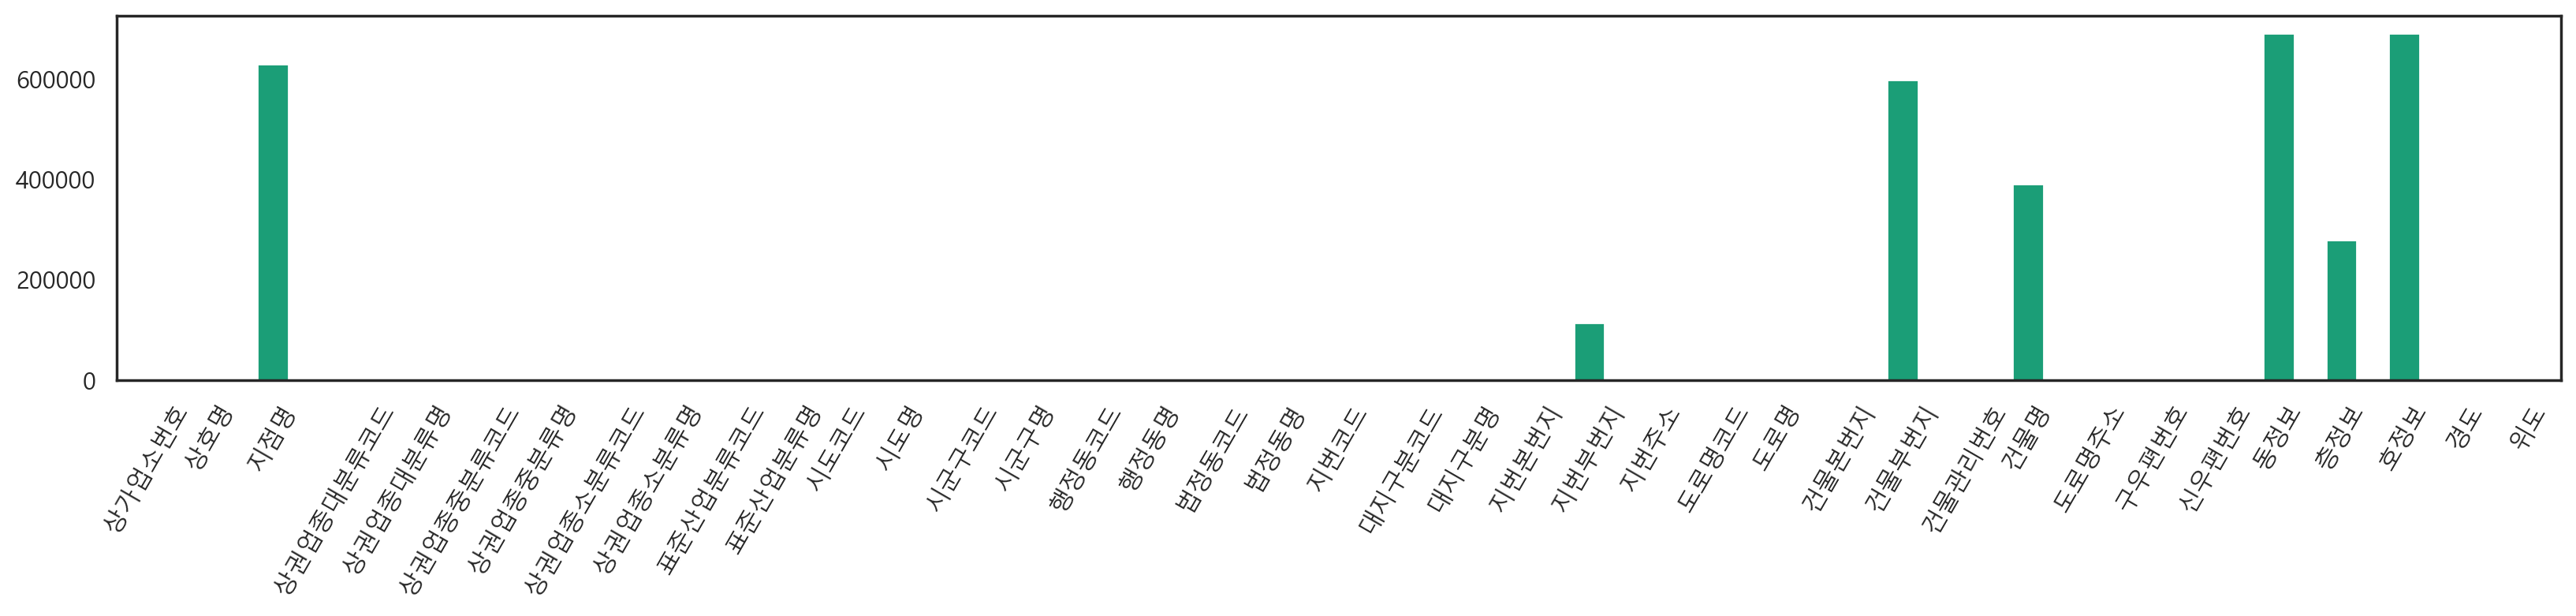

In [78]:
#missing_cnt.plot.bar()
missing_cnt.plot(kind='bar', figsize=(20,3), rot=60)
plt.show()

In [80]:
missing_cnt_sorted = missing_cnt.sort_values(ascending=False)
missing_cnt_sorted.head(2)

호정보    692592
동정보    692592
dtype: int64

<Axes: >

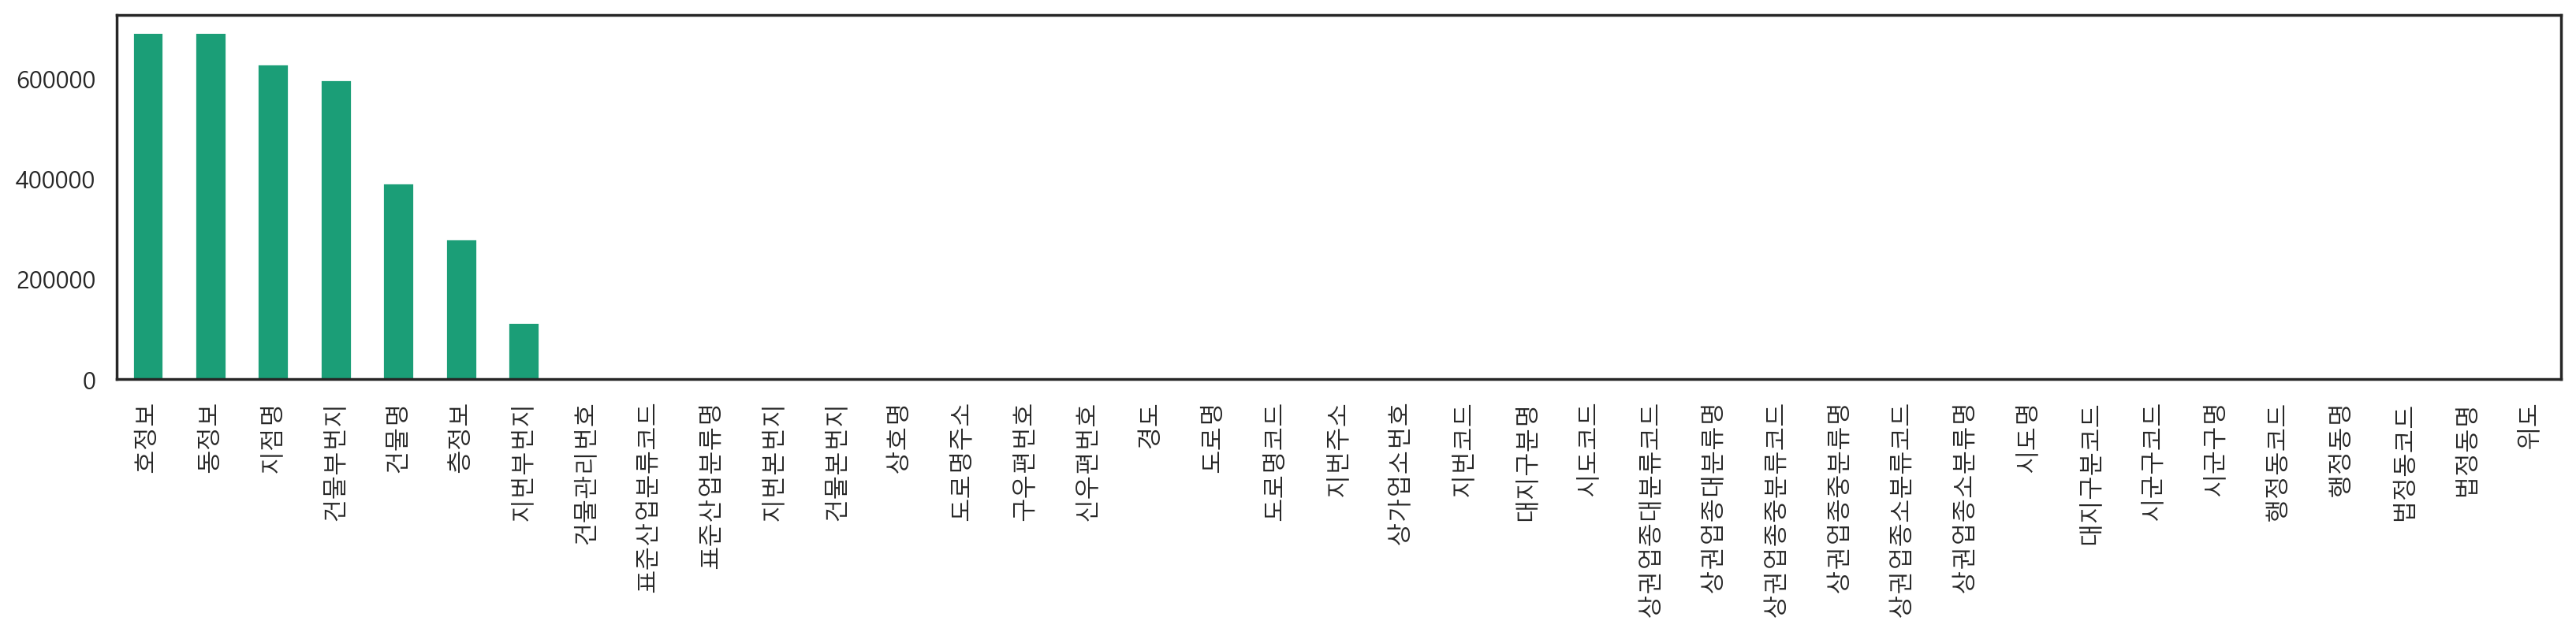

In [81]:
missing_cnt_sorted.plot(kind='bar', figsize=(20,3))

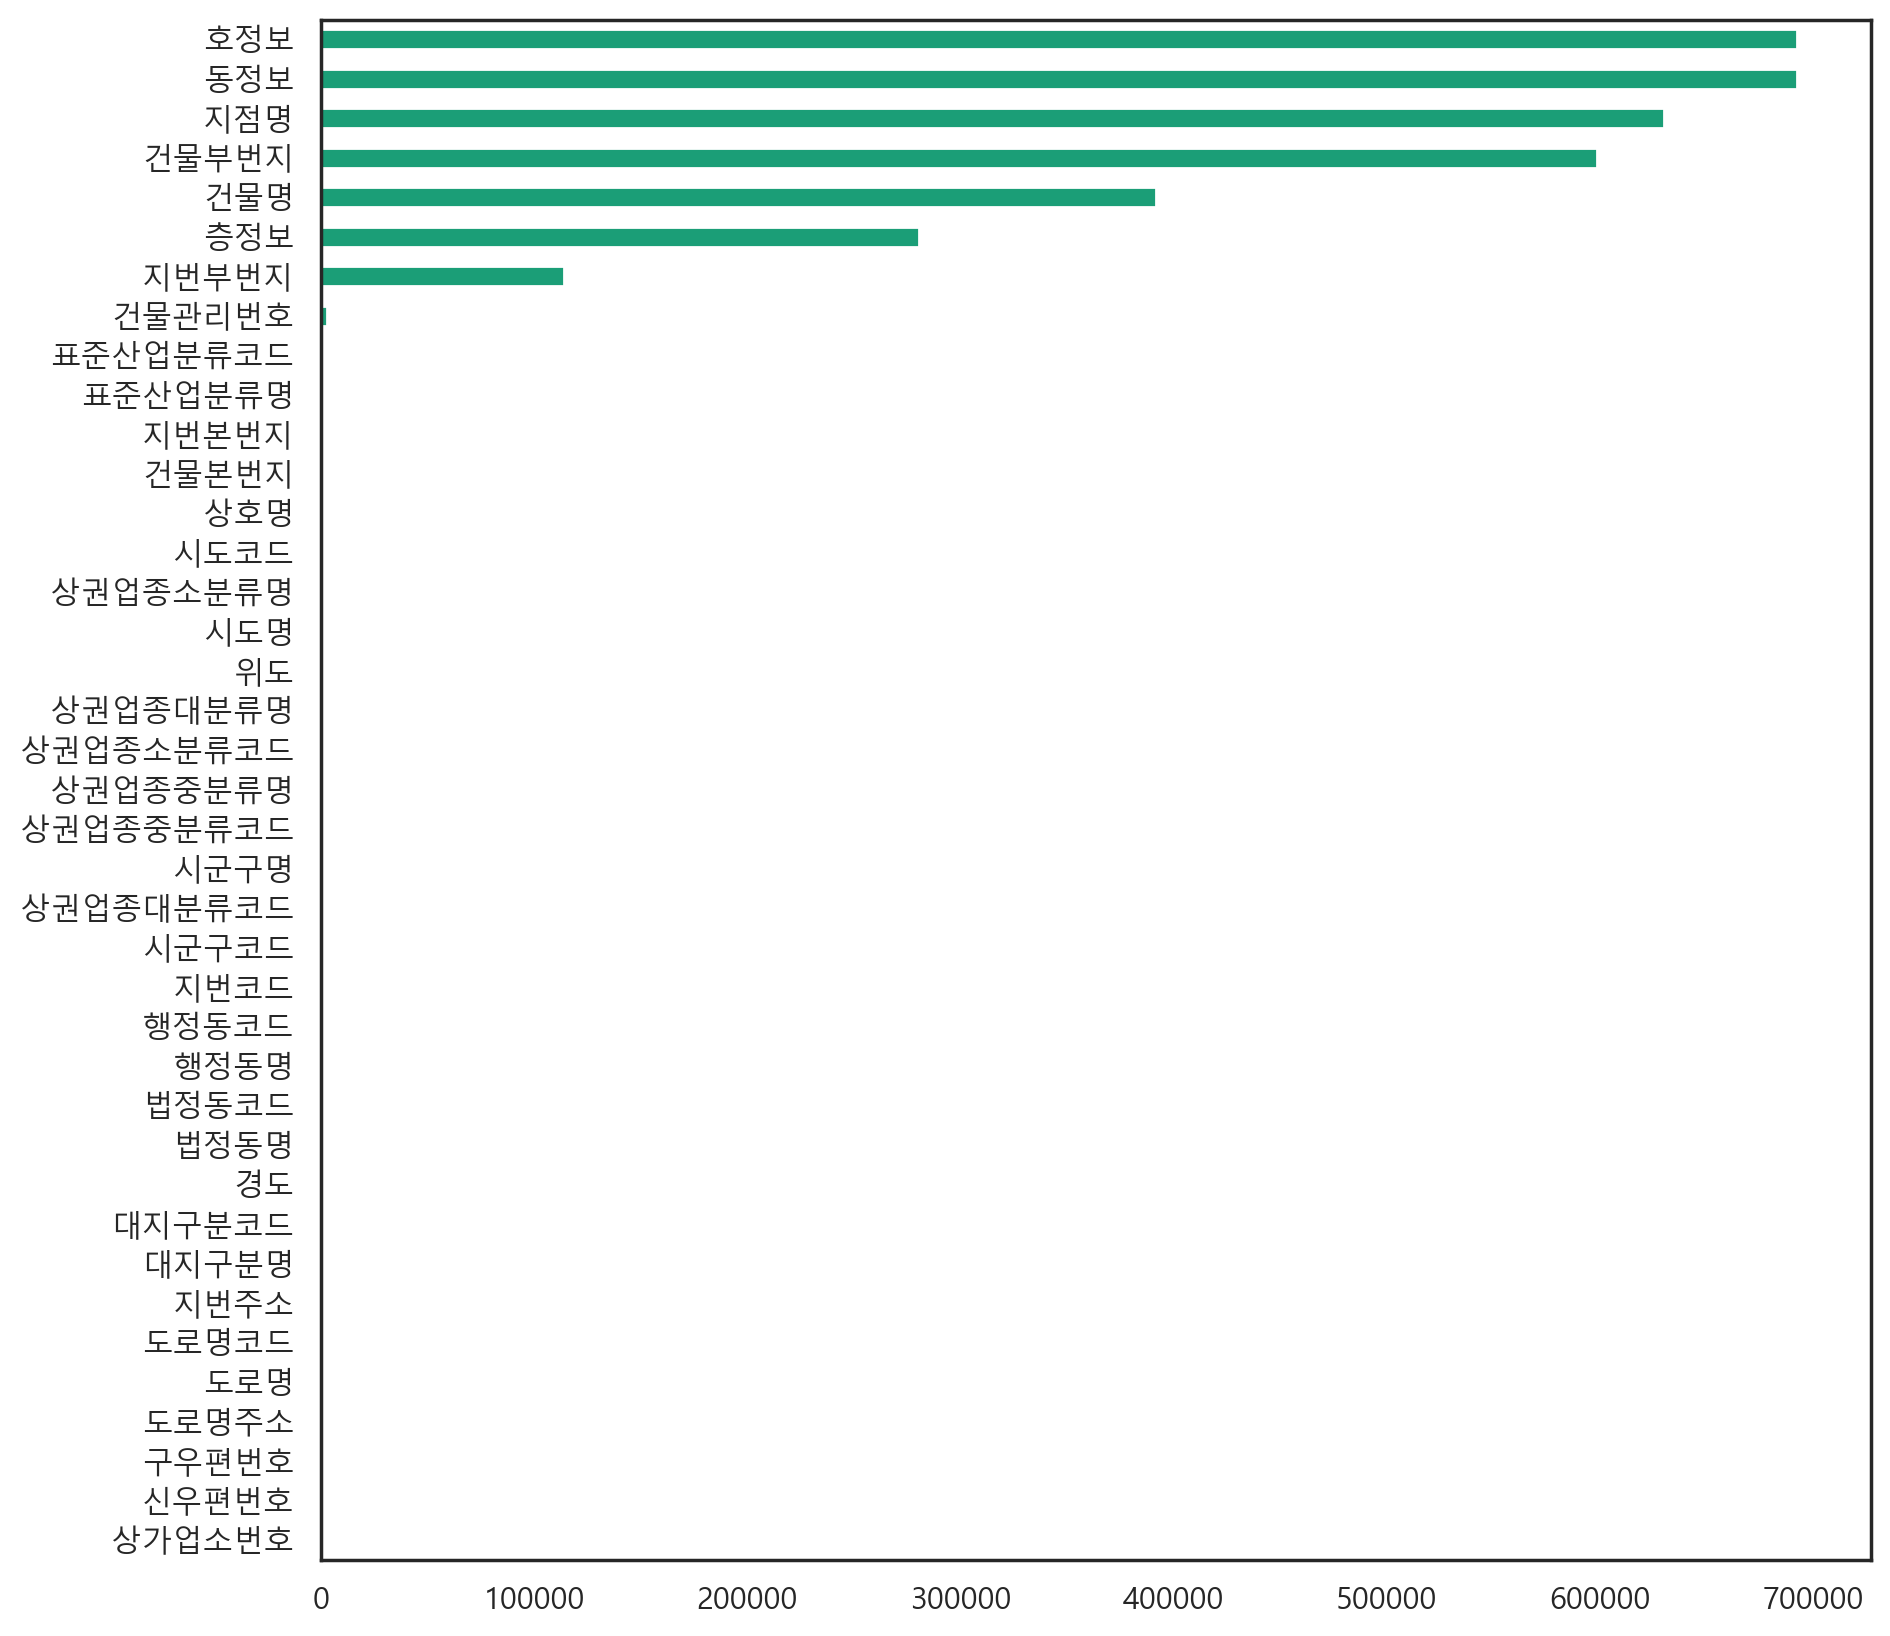

In [85]:
missing_cnt.sort_values().plot(kind='barh', figsize=(10,10))
plt.show()

## ④ 결측치가 없는 컬럼는 제외하고 시각화(정렬전 bar plot, barh plot, 정렬 후 bar plot, barh plot).

In [91]:
# 결측치가 있는 열만 
only_missing_cnt = missing_cnt[missing_cnt!=0]
for i, (col, val) in enumerate(only_missing_cnt.items()):
    print(i, col, val)

0 상호명 1
1 지점명 630376
2 표준산업분류코드 211
3 표준산업분류명 211
4 지번본번지 29
5 지번부번지 113977
6 건물본번지 2
7 건물부번지 598859
8 건물관리번호 2912
9 건물명 391896
10 동정보 692592
11 층정보 280540
12 호정보 692592


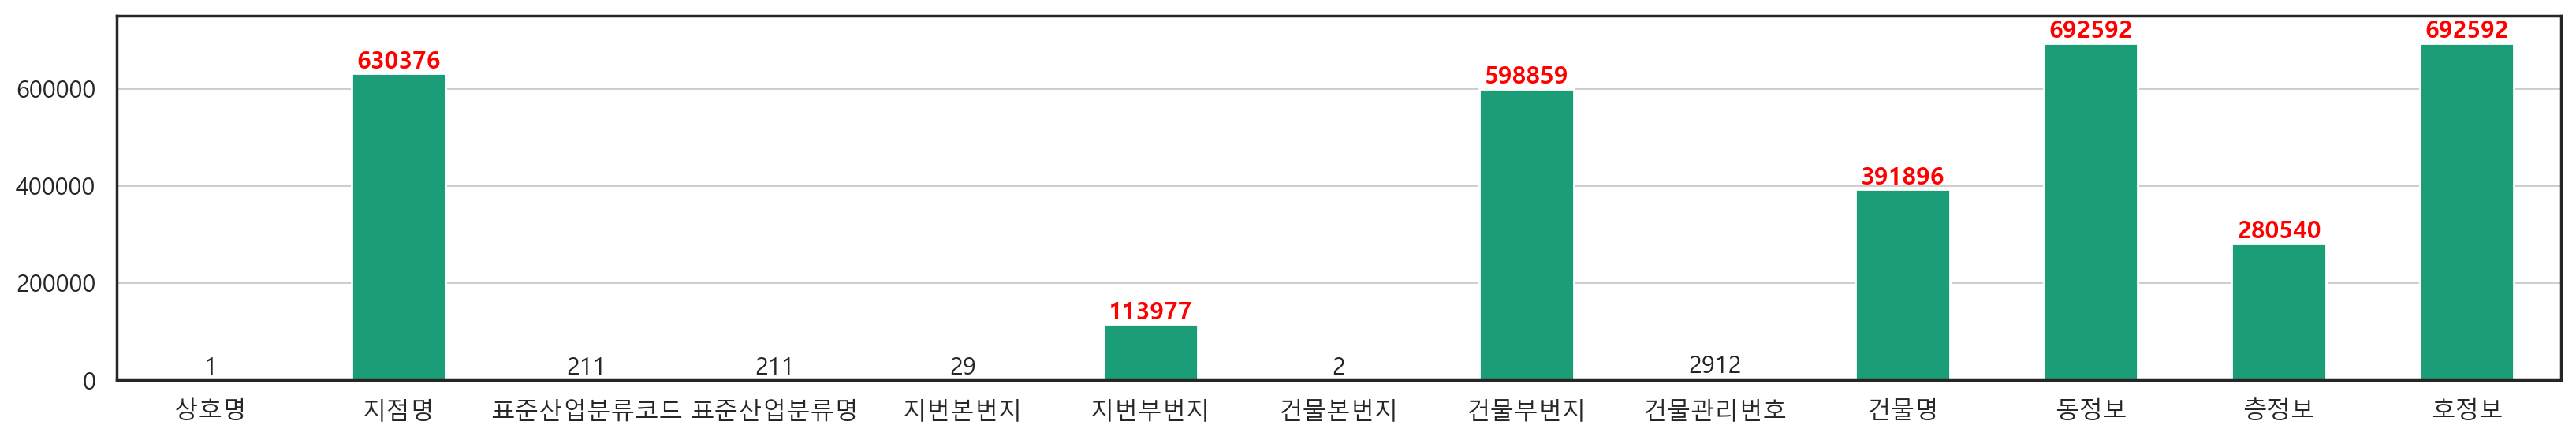

In [103]:
only_missing_cnt.plot(kind='bar', rot=0, figsize=(20,3),
                     ylim=[0, 750000])
for i, v in enumerate(only_missing_cnt):
    if v>100000:
        plt.text(i, v, round(v), va='bottom', ha='center', size=11, color='r', weight='bold')
    else:
        plt.text(i, v, round(v), va='bottom', ha='center', size=11)
plt.grid(axis='y')

In [110]:
# data : only_missing_cnt.to_frame()
# x축 : index
# y축 : 0열
result = only_missing_cnt.to_frame()
result.columns = ['결측치수']
result.head()

,결측치수
상호명,1
지점명,630376
표준산업분류코드,211
표준산업분류명,211
지번본번지,29


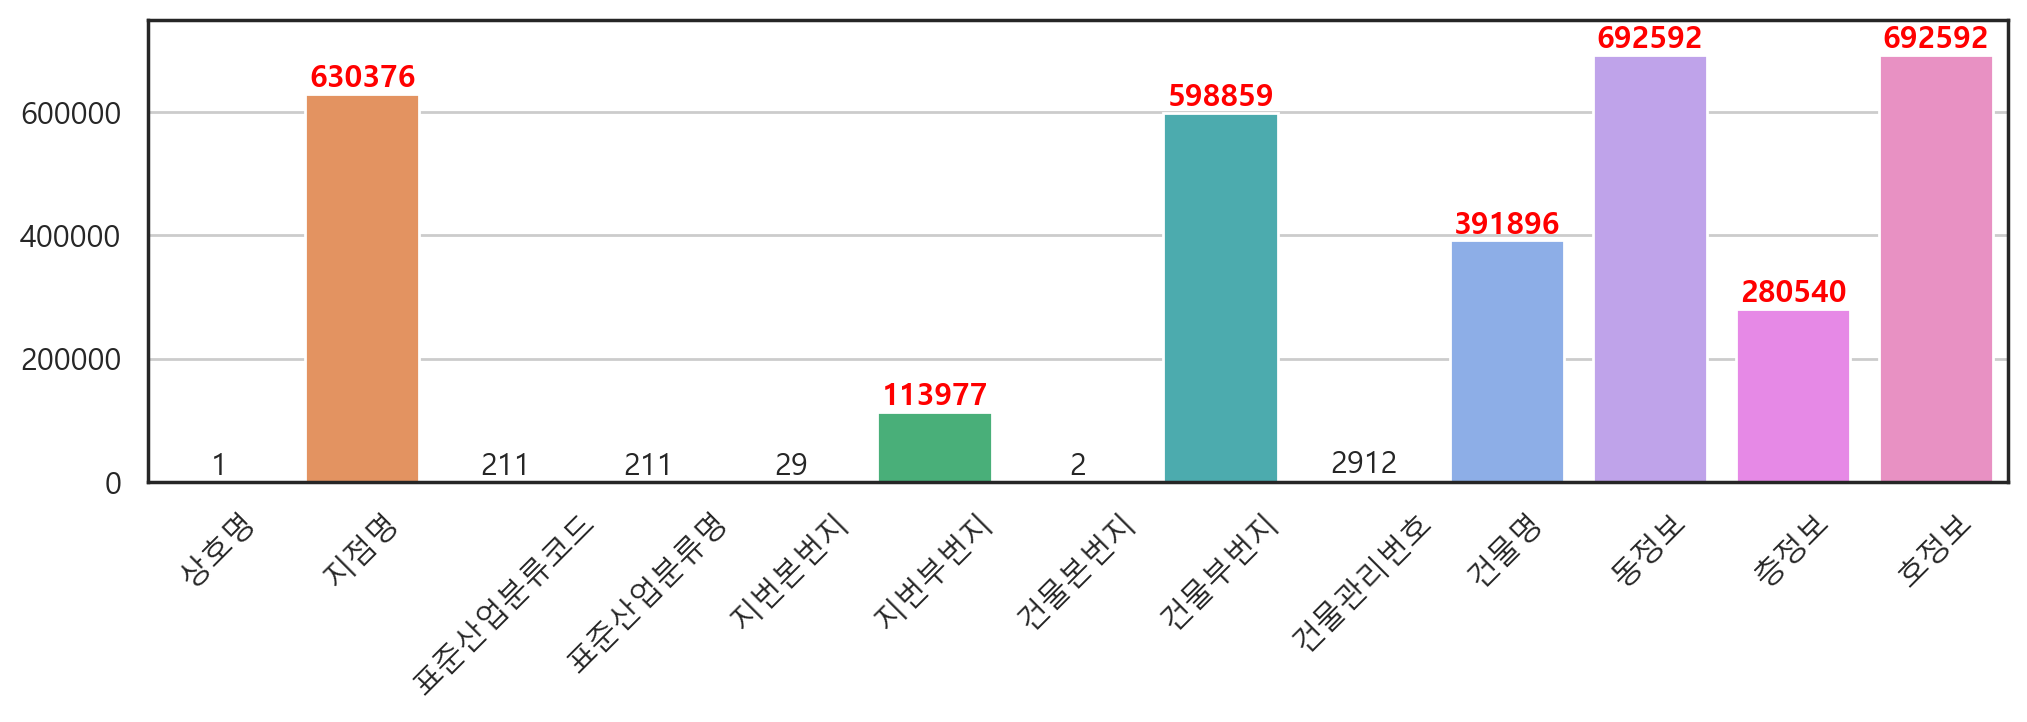

In [117]:
#sns.barplot(data=result, x = result.index, y = '결측치수')
sns.barplot(x=only_missing_cnt.index,
           y=only_missing_cnt)
for i, v in enumerate(only_missing_cnt):
    if v>100000:
        plt.text(i, v, round(v), va='bottom', ha='center', size=11, color='r', weight='bold')
    else:
        plt.text(i, v, round(v), va='bottom', ha='center', size=11)
plt.ylim(0, 750000)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## ⑤ missingno 라이브러리로 결측치 시각화
* [ResidentMario/missingno: Missing data visualization module for Python](https://github.com/ResidentMario/missingno)

* 위의 사이트를 열어 사용법 확인
아나콘다 프롬프트에서 라이브러리 install : `pip install missingno`

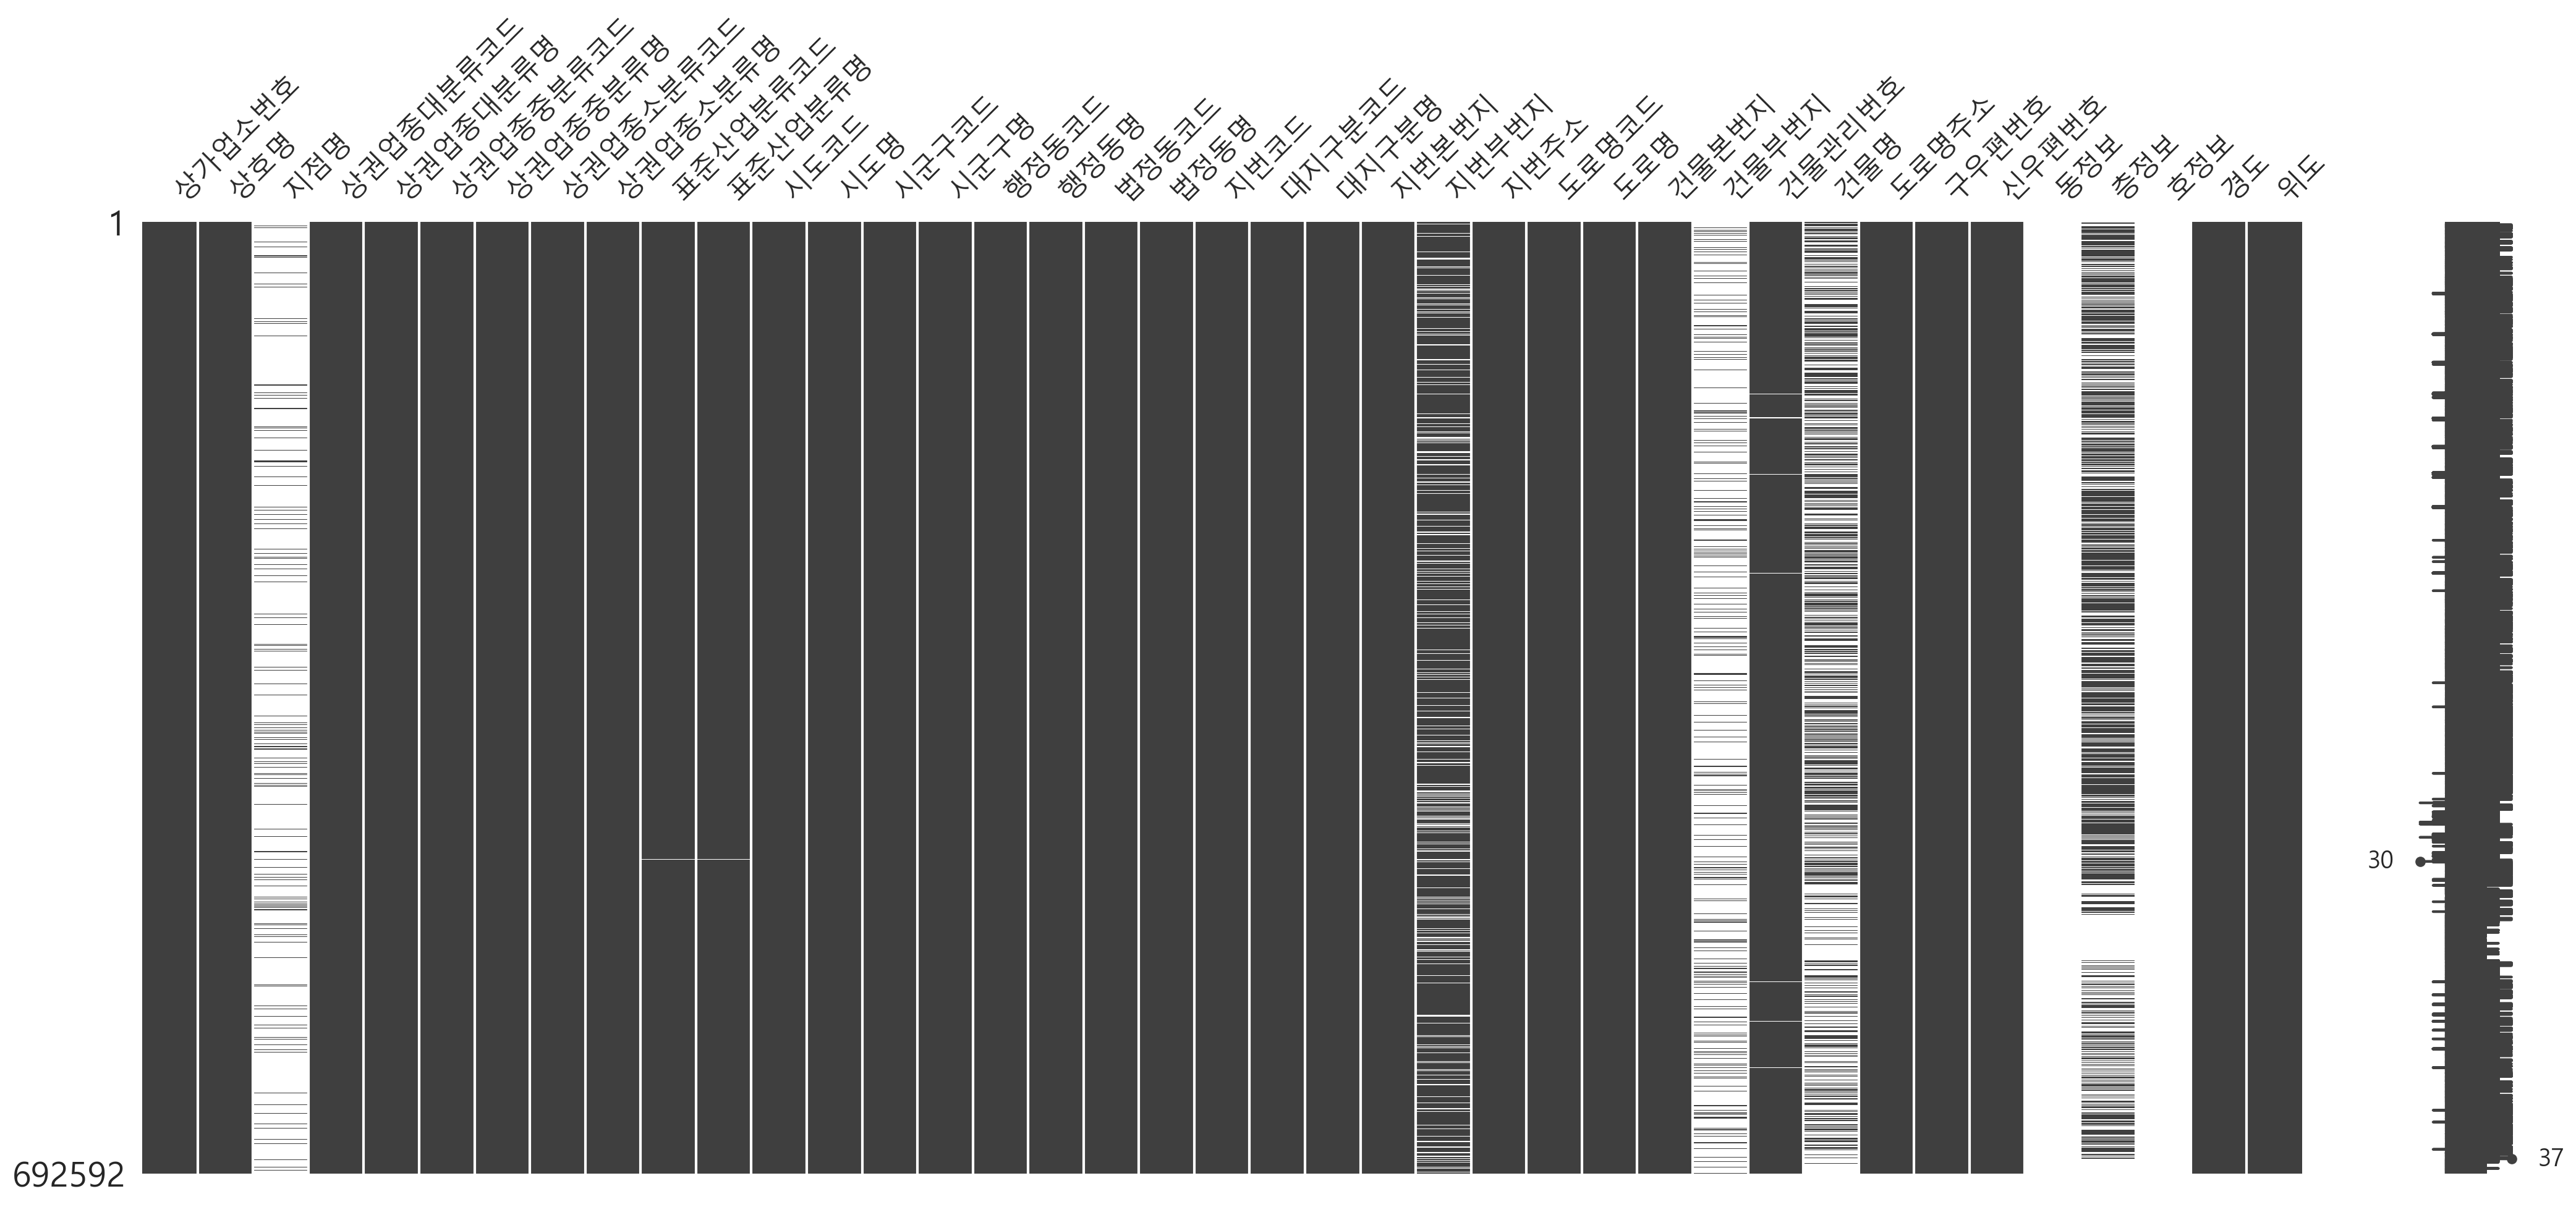

In [118]:
import missingno as msno
msno.matrix(df) # 결측치가 없는 부분은 검정색. 결측치 부분은 흰색
plt.show()

<Axes: >

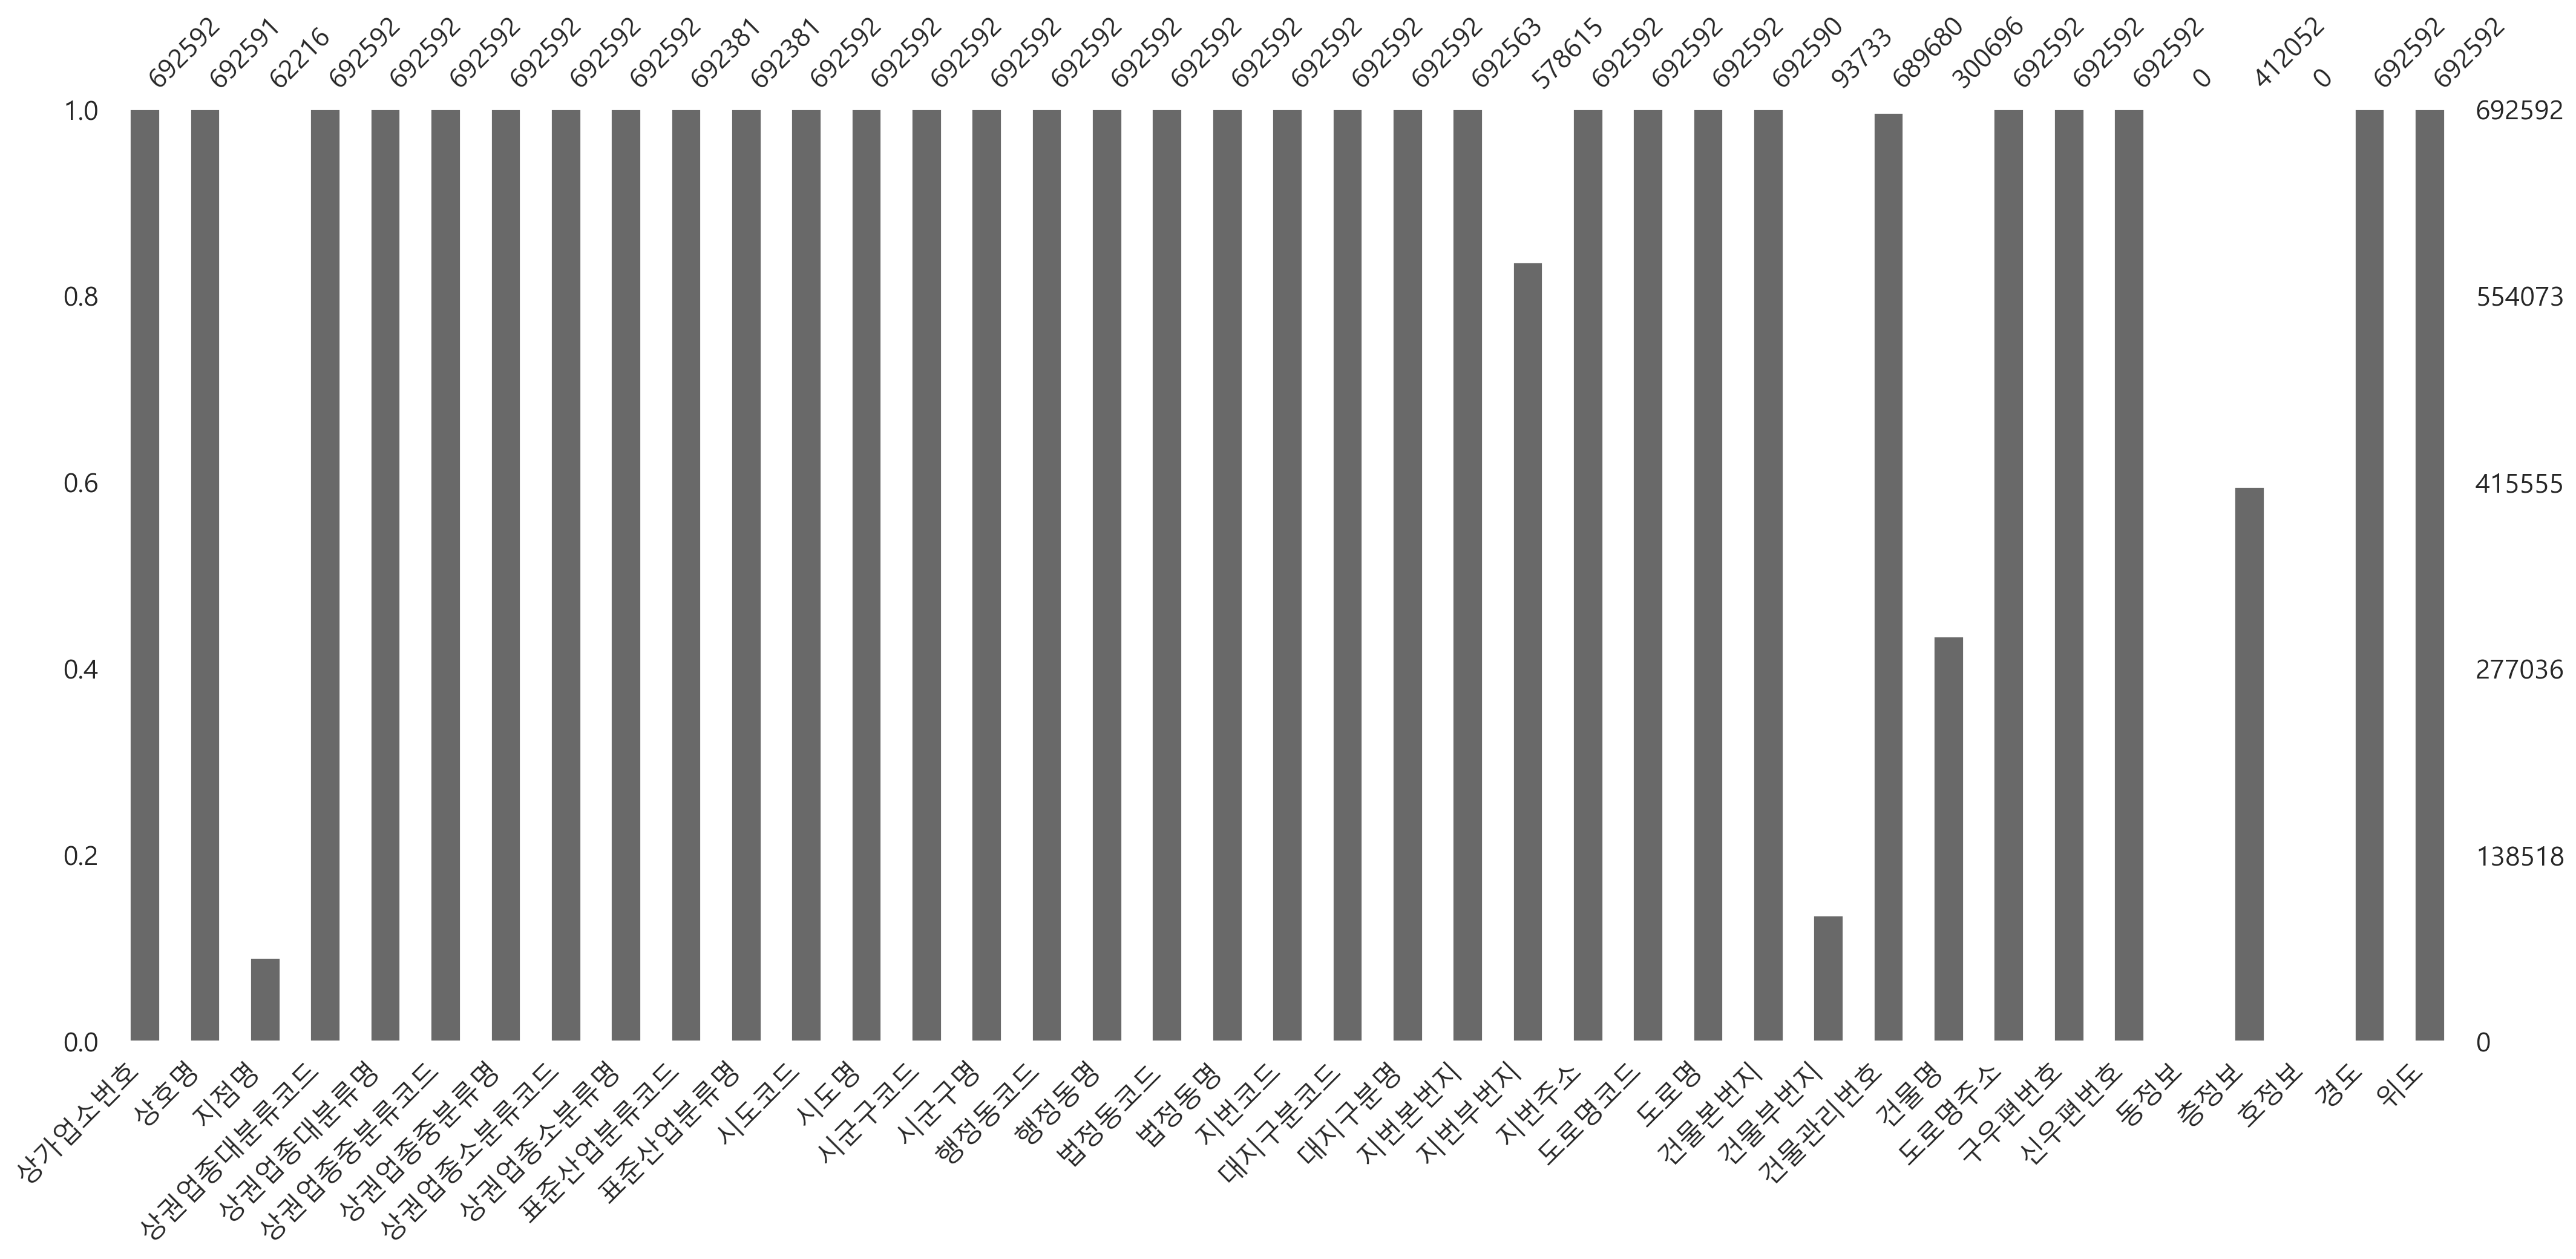

In [119]:
msno.bar(df) # 결측치가 아닌 데이터 갯수를 포함한 barplot

# 4.	df 데이터 셋에서 사용하지 않을 컬럼은 제거
## ①결측치가 너무 많은 컬럼은 제거한다. 결측치가 너무 많은 상위 7개 컬럼은 제거함.


In [122]:
# 결측치가 많은 컬럼명과 결측치 수
not_use = df.isnull().sum().sort_values(ascending=False).head(7)
not_use

호정보      692592
동정보      692592
지점명      630376
건물부번지    598859
건물명      391896
층정보      280540
지번부번지    113977
dtype: int64

In [128]:
# 결측치 비율
round(not_use / df.shape[0] * 100, 2)

호정보      100.00
동정보      100.00
지점명       91.02
건물부번지     86.47
건물명       56.58
층정보       40.51
지번부번지     16.46
dtype: float64

In [129]:
# 삭제할 컬럼명
not_use.index

Index(['호정보', '동정보', '지점명', '건물부번지', '건물명', '층정보', '지번부번지'], dtype='object')

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 39 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   상가업소번호     692592 non-null  object 
 1   상호명        692591 non-null  object 
 2   지점명        62216 non-null   object 
 3   상권업종대분류코드  692592 non-null  object 
 4   상권업종대분류명   692592 non-null  object 
 5   상권업종중분류코드  692592 non-null  object 
 6   상권업종중분류명   692592 non-null  object 
 7   상권업종소분류코드  692592 non-null  object 
 8   상권업종소분류명   692592 non-null  object 
 9   표준산업분류코드   692381 non-null  object 
 10  표준산업분류명    692381 non-null  object 
 11  시도코드       692592 non-null  int64  
 12  시도명        692592 non-null  object 
 13  시군구코드      692592 non-null  int64  
 14  시군구명       692592 non-null  object 
 15  행정동코드      692592 non-null  int64  
 16  행정동명       692592 non-null  object 
 17  법정동코드      692592 non-null  int64  
 18  법정동명       692592 non-null  object 
 19  지번코드       692592 non-n

In [134]:
# 컬럼 삭제 전(206.1+MB), 컬럼수39개
print('컬럼 제거 전 shape :', df.shape)
df = df.drop(not_use.index, axis=1)
# 컬럼 삭제 후 컬럼수
print('컬럼 제거 후 shape :', df.shape)

컬럼 제거 전 shape : (692592, 39)
컬럼 제거 후 shape : (692592, 32)


## ②	컬럼명에 “코드”나 “번호”가 있는 컬럼은 분석에 사용되지 않을 예정입니다. 제거함

In [135]:
# 컬럼명
cols = df.columns
cols

Index(['상가업소번호', '상호명', '상권업종대분류코드', '상권업종대분류명', '상권업종중분류코드', '상권업종중분류명',
       '상권업종소분류코드', '상권업종소분류명', '표준산업분류코드', '표준산업분류명', '시도코드', '시도명', '시군구코드',
       '시군구명', '행정동코드', '행정동명', '법정동코드', '법정동명', '지번코드', '대지구분코드', '대지구분명',
       '지번본번지', '지번주소', '도로명코드', '도로명', '건물본번지', '건물관리번호', '도로명주소', '구우편번호',
       '신우편번호', '경도', '위도'],
      dtype='object')

**※ 시리즈에 문자함수를 쓰기 위해 참조 :**
https://pandas.pydata.org/pandas-docs/stable/reference/series.html#string-handling

In [141]:
# cols에 코드나 번호가 포함되어 있는 컬럼명 추출
cols[(cols.str.find('코드')!=-1) | (cols.str.find('번호')!=-1)]

Index(['상가업소번호', '상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '표준산업분류코드', '시도코드',
       '시군구코드', '행정동코드', '법정동코드', '지번코드', '대지구분코드', '도로명코드', '건물관리번호', '구우편번호',
       '신우편번호'],
      dtype='object')

In [144]:
drop_cols = cols[cols.str.contains('코드|번호')]
drop_cols

Index(['상가업소번호', '상권업종대분류코드', '상권업종중분류코드', '상권업종소분류코드', '표준산업분류코드', '시도코드',
       '시군구코드', '행정동코드', '법정동코드', '지번코드', '대지구분코드', '도로명코드', '건물관리번호', '구우편번호',
       '신우편번호'],
      dtype='object')

In [146]:
df.drop(drop_cols, axis=1, inplace=True)
print('열 제거 후 shape :', df.shape) 

열 제거 후 shape : (692592, 17)


In [147]:
df.info() # 89.8+ MB

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 17 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   상호명       692591 non-null  object 
 1   상권업종대분류명  692592 non-null  object 
 2   상권업종중분류명  692592 non-null  object 
 3   상권업종소분류명  692592 non-null  object 
 4   표준산업분류명   692381 non-null  object 
 5   시도명       692592 non-null  object 
 6   시군구명      692592 non-null  object 
 7   행정동명      692592 non-null  object 
 8   법정동명      692592 non-null  object 
 9   대지구분명     692592 non-null  object 
 10  지번본번지     692563 non-null  float64
 11  지번주소      692592 non-null  object 
 12  도로명       692592 non-null  object 
 13  건물본번지     692590 non-null  float64
 14  도로명주소     692592 non-null  object 
 15  경도        692592 non-null  float64
 16  위도        692592 non-null  float64
dtypes: float64(4), object(13)
memory usage: 89.8+ MB


# ※ df 파일io

In [148]:
df.to_csv('c:/ai/downloads/shareData/상가정보/서울부산상가정보백업.csv', index=False)

In [151]:
df.to_csv('c:/ai/downloads/shareData/상가정보/서울부산상가정보백업.csv.zip', 
          index=False, 
          compression='infer')

In [152]:
df = pd.read_csv('c:/ai/downloads/shareData/상가정보/서울부산상가정보백업.csv')
df.shape

(692592, 17)

# 5. df 데이터 셋의 값을 가져온다(loc함수, iloc함수등을 사용하기도 하고 사용하지 않기도 하며 서브셋을 가져온다)
## ① 상호명 필드만 가져온다


In [155]:
df['상호명']
df.loc[:, '상호명']

0              참편한공인중개사사무소
1                  60계치킨암사
2                   성심인력공사
3                      칸토빈
4                  까치노래연습장
                ...       
692587        사회적협동조합 희망드림
692588                제주식품
692589                신천횟집
692590    주식회사  스타라이팅 일광지점
692591             이한나탁구클럽
Name: 상호명, Length: 692592, dtype: object

## ②상호명의 종류별 데이터수를 가져온다(df.상호명.value_counts()이용)

In [157]:
df['상호명'].unique()

array(['참편한공인중개사사무소', '60계치킨암사', '성심인력공사', ..., '제주식품', '신천횟집',
       '주식회사  스타라이팅 일광지점'], dtype=object)

In [164]:
# 상호명별 데이터 갯수
df.groupby('상호명')['경도'].count().sort_values(ascending=False).head()

상호명
업소명없음      793
컴퓨터수리      497
입시·교과학원    288
입주청소       262
김밥천국       214
Name: 경도, dtype: int64

In [165]:
df['상호명'].value_counts() # 정렬

업소명없음               793
컴퓨터수리               497
입시·교과학원             288
입주청소                262
김밥천국                214
                   ... 
손가네곰국수                1
대한어머니회서울시연합사          1
소월마인드풀요가              1
우림인쇄                  1
주식회사  스타라이팅 일광지점      1
Name: 상호명, Length: 535061, dtype: int64

## ③	“상호명”과 "도로명주소” 컬럼 가져오기

In [166]:
df[['상호명','도로명주소']]

,상호명,도로명주소
0,참편한공인중개사사무소,서울특별시 서초구 방배로19길 25
1,60계치킨암사,서울특별시 강동구 상암로3길 8
2,성심인력공사,서울특별시 용산구 한강대로 385
3,칸토빈,서울특별시 강서구 방화동로 30
4,까치노래연습장,서울특별시 노원구 한글비석로23길 2
...,...,...
692587,사회적협동조합 희망드림,부산광역시 동구 조방로 14
692588,제주식품,부산광역시 남구 동명로152번길 93
692589,신천횟집,부산광역시 중구 자갈치해안로 52
692590,주식회사 스타라이팅 일광지점,부산광역시 기장군 일광읍 일광로 808


## ④ 0~2행을 출력하라 (head()함수를 이용하지 않고, loc과 iloc을 이용)

In [170]:
df.loc[:2]
df.iloc[:3]
df[:3] # 조건, 열이름, 행슬라이싱 등이 데이터프레임변수[]안에 (열슬라이싱은 불가)

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번본번지,지번주소,도로명,건물본번지,도로명주소,경도,위도
0,참편한공인중개사사무소,부동산,부동산 서비스,부동산 중개/대리업,부동산 중개 및 대리업,서울특별시,서초구,방배1동,방배동,대지,927.0,서울특별시 서초구 방배동 927-35,서울특별시 서초구 방배로19길,25.0,서울특별시 서초구 방배로19길 25,126.993691,37.484844
1,60계치킨암사,음식,기타 간이,치킨,치킨 전문점,서울특별시,강동구,암사2동,암사동,대지,502.0,서울특별시 강동구 암사동 502-4,서울특별시 강동구 상암로3길,8.0,서울특별시 강동구 상암로3길 8,127.126859,37.550810
2,성심인력공사,시설관리·임대,고용 알선,고용 알선업,고용 알선업,서울특별시,용산구,남영동,동자동,대지,43.0,서울특별시 용산구 동자동 43-59,서울특별시 용산구 한강대로,385.0,서울특별시 용산구 한강대로 385,126.972240,37.552803


# 6. 기술 통계값 보기 

- [Descriptive statistics - Wikipedia](https://en.wikipedia.org/wiki/Descriptive_statistics)
- [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
- [표준 편차 - 위키백과, 우리 모두의 백과사전](https://ko.wikipedia.org/wiki/표준편차)
* describe()를 사용하면 데이터 요약을 볼 수 있음(기술통계량)
    - 기본적으로 수치형 데이터를 요약
    - include, exclude 옵션으로 다른 데이터 타입의 요약 수치 출력
    - count, min, max, mean, median, 1사분위수, 3사분위수

### **개별 기술 통계값 구하기**

* [Computations / descriptive stats](https://pandas.pydata.org/docs/reference/frame.html#computations-descriptive-stats)
* count : 결측치를 제외한 값 갯수
* min, max: 최솟값, 최댓값
* argmin, argmax : 최솟값 인덱스, 최댓값 인덱스 반환
* quantile 특정 사분위수에 해당하는 값을 반환 (0~1 사이)
    * 0.25 : 1사분위 수
    * 0.5 : 2사분위수 (quantile 의 기본 값)
    * 0.75 : 3사분위수
* sum 수치 데이터의 합계
* mean 평균
* median 중앙값(중간값:데이터를 한 줄로 세웠을 때 가운데 위치하는 값, 중앙값이 짝수일 때는 가운데 2개 값의 평균을 구함)

* std, var 표준편차, 분산을 계산
* cumsum 맨 첫 번째 성분부터 각 성분까지의 누적합을 계산 (0 번째 부터 계속 더해짐)
* cumprod 맨 첫번째 성분부터 각 성분까지의 누적곱을 계산 (1 번째 부터 계속 곱해짐)
* cov, corr() : 공분산, 상관계수
* skew 왜도 (오른쪽으로 치우침= 왜도<0, 왼쪽으로 치우침=왜도>0)
* kurt 첨도


## ①	df 데이터셋의 요약기술 통계량

In [176]:
# DataFrame.count: Count number of non-NA/null observations.
# DataFrame.max: Maximum of the values in the object.
# DataFrame.min: Minimum of the values in the object.
# DataFrame.mean: Mean of the values.
# DataFrame.std: Standard deviation of the observations.
df.describe() # 수치형에 대한 기술통계량

,지번본번지,건물본번지,경도,위도
count,692563.000000,692590.000000,692592.000000,692592.000000
mean,484.421211,144.045545,127.457120,37.008934
std,518.267621,264.093185,0.867369,0.991261
min,1.000000,1.000000,126.767661,34.989747
25%,112.000000,19.000000,126.943926,37.474629
50%,337.000000,47.000000,127.034613,37.514822
75%,688.000000,152.000000,127.131254,37.560404
max,6435.000000,3646.000000,129.294072,37.692604


In [177]:
df.describe(include='object') #object형에 대한 기술 통계량

,상호명,상권업종대분류명,상권업종중분류명,상권업종소분류명,표준산업분류명,시도명,시군구명,행정동명,법정동명,대지구분명,지번주소,도로명,도로명주소
count,692591,692592,692592,692592,692381,692592,692592,692592,692592,692592,692592,692592,692592
unique,535061,10,75,247,386,2,39,630,647,2,221186,18817,220936
top,업소명없음,음식,한식,백반/한정식,한식 일반 음식점업,서울특별시,강남구,역삼1동,서초동,대지,서울특별시 송파구 문정동 634,서울특별시 강남구 테헤란로,서울특별시 송파구 충민로 66
freq,793,190725,75607,39765,60780,537489,64239,13420,17901,691744,881,4248,1123


## ②	df 데이터셋의 “지번본번지", "건물본번지” 컬럼의 데이터 개수와  dtype 메모리 사용량을 확인한다.

In [191]:
df[['지번본번지','건물본번지']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 692592 entries, 0 to 692591
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   지번본번지   692563 non-null  float64
 1   건물본번지   692590 non-null  float64
dtypes: float64(2)
memory usage: 10.6 MB


## ③	“위도", "경도” 컬럼만의 요약 기술통계량

In [194]:
df[['위도','경도']].describe()
# 오른쪽 꼬리가 긴 분포(데이터가 왼쪽으로 취우침) : 중위수 < 평균 - 왜도(skew)>0
# 왼쪽 꼬리가 긴 분포(데이터가 오른쪽으로 취우침) : 평균 < 중위수 - 왜도(skew)<0

,위도,경도
count,692592.000000,692592.000000
mean,37.008934,127.457120
std,0.991261,0.867369
min,34.989747,126.767661
25%,37.474629,126.943926
50%,37.514822,127.034613
75%,37.560404,127.131254
max,37.692604,129.294072


# 7.단별량 수치형 변수 시각화
## ① 위도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

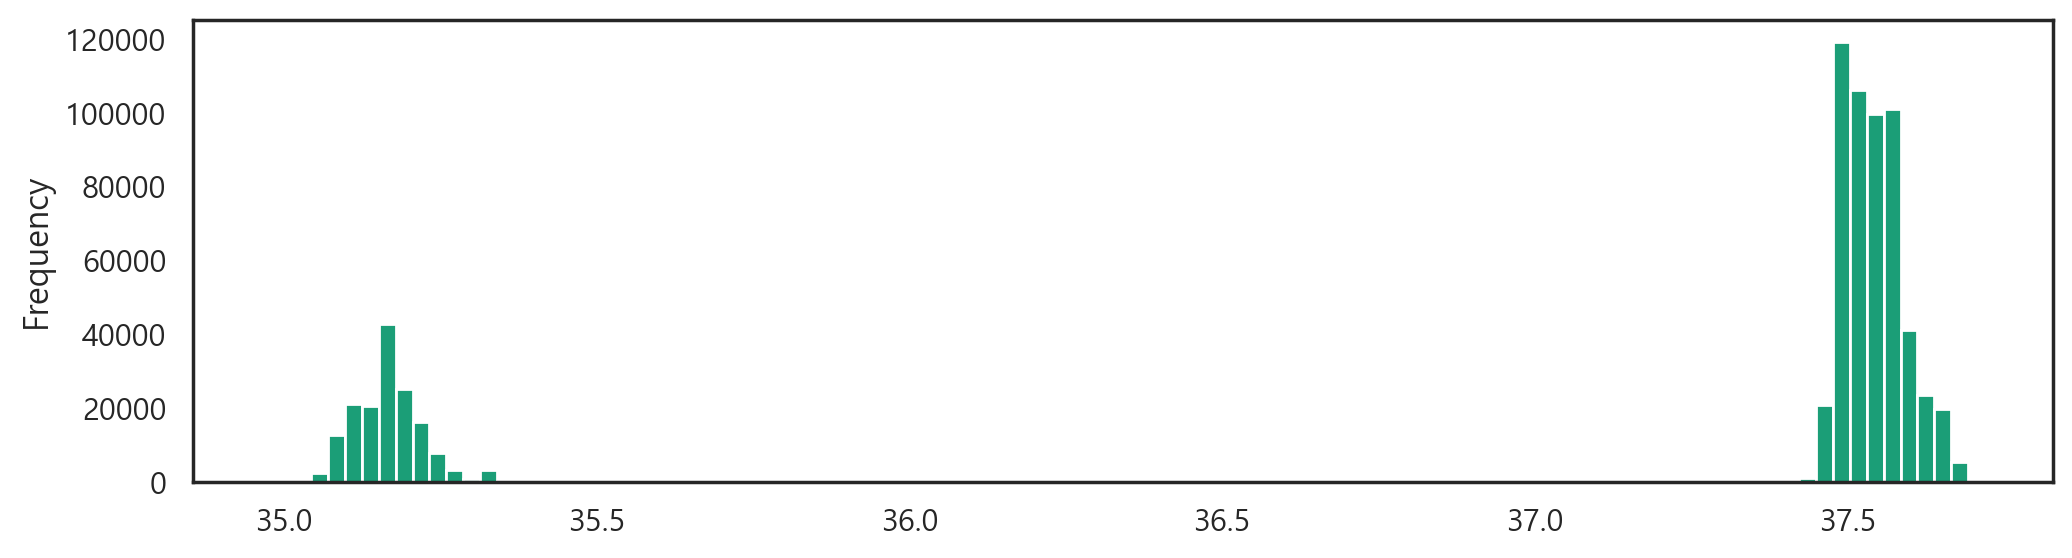

In [202]:
# df['위도'].plot(kind='hist', bins=100)
df['위도'].plot.hist(bins=100)
plt.show()

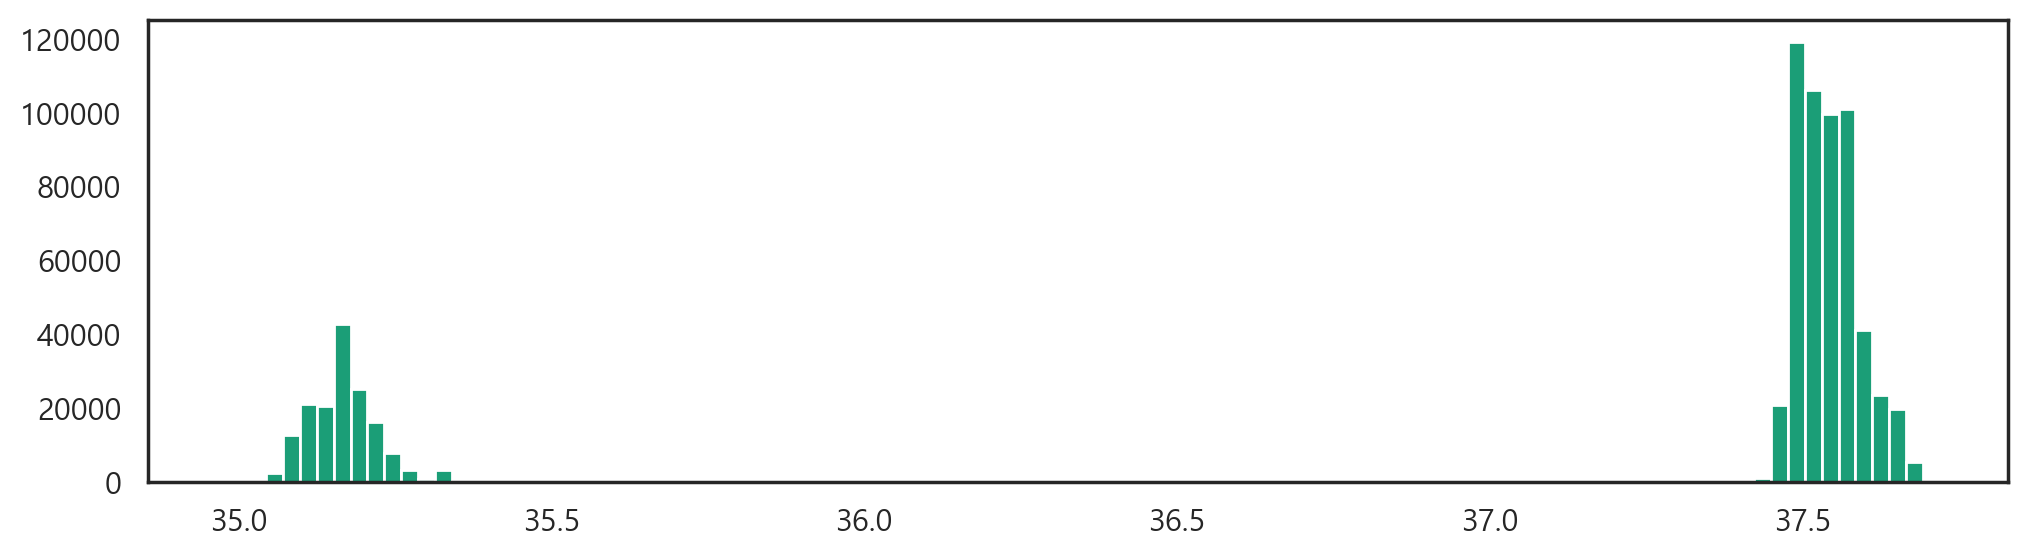

In [204]:
plt.hist(df['위도'], bins=100)
plt.show()

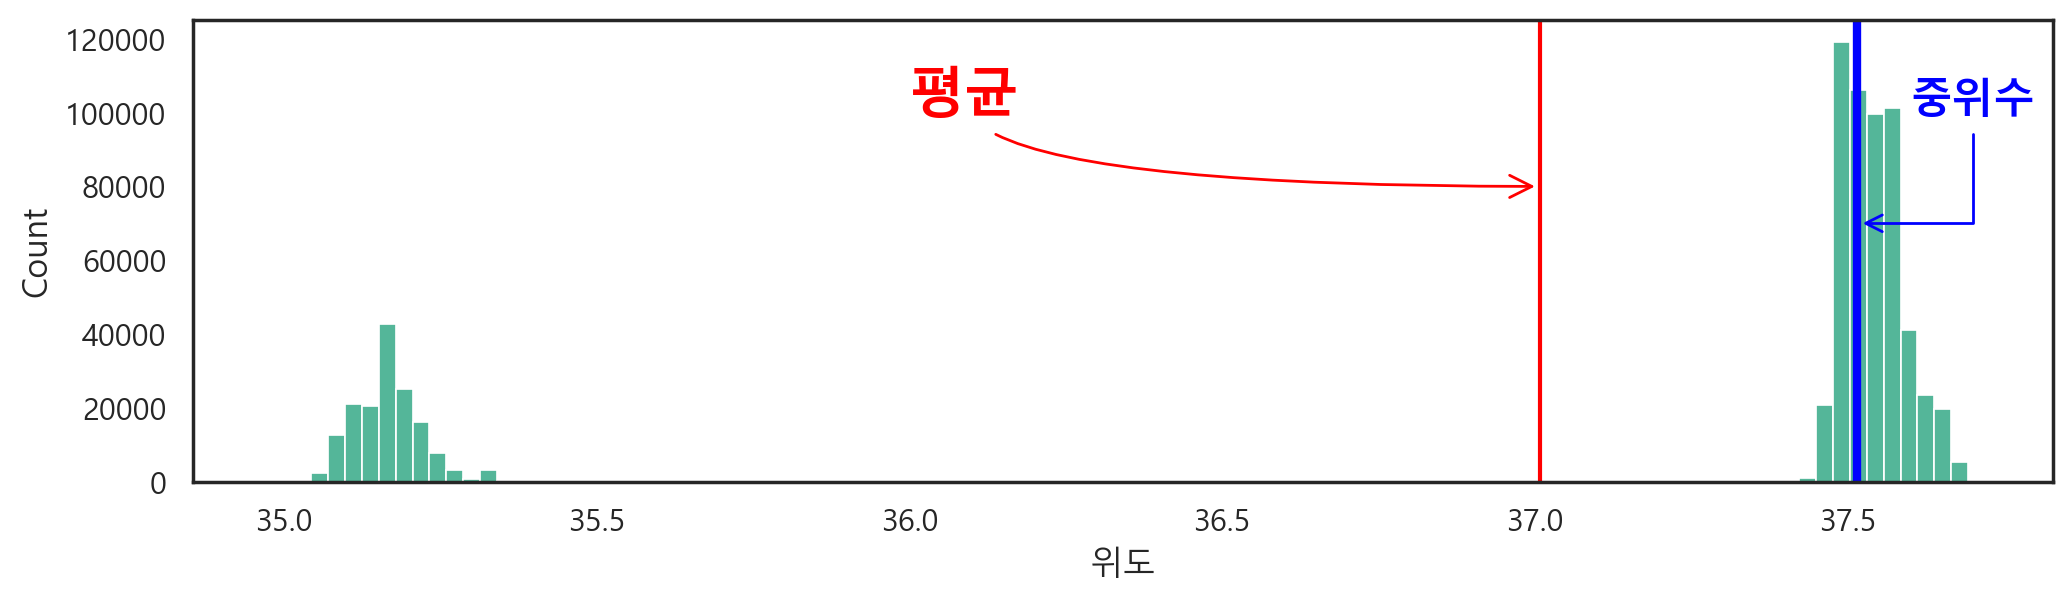

In [219]:
sns.histplot(data=df, x='위도', bins=100)
plt.axvline(df['위도'].mean(), color='r')
plt.annotate('평균',
            xytext=(36,100000), # 글자 위치
            xy = (df['위도'].mean(), 80000), # 화살표가 가리킬 좌표
            arrowprops={'arrowstyle':'->',
                       'connectionstyle':'angle3', # angle, arc, ..
                        'color':'r'},
            fontsize=20,
            weight='bold',
            color='r')
plt.axvline(df['위도'].median(), color='b', linewidth=3)
plt.annotate('중위수',
            xytext=(37.6, 100000),
            xy=(df['위도'].median(), 70000),
            arrowprops=dict(arrowstyle='->',
                           connectionstyle='angle',
                           color='b'),
            color='b',
            weight='bold',
            fontsize=15)
plt.show()

In [221]:
df['위도'].skew()

-1.3201510434921953

## ② 경도의 빈도표를 시각화 : plot.hist, hist, sns.displot, sns.histplot

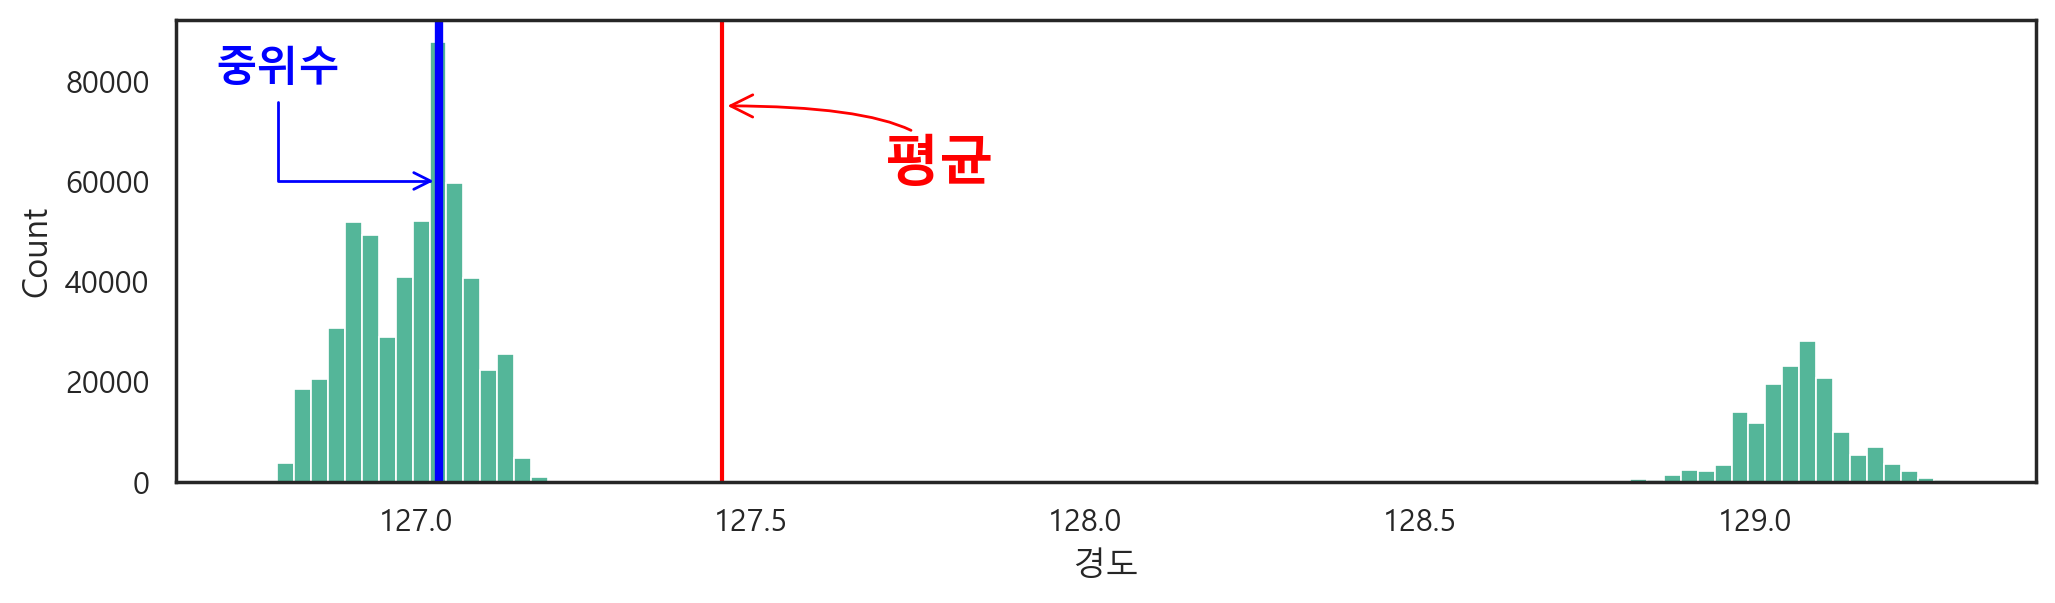

In [229]:
sns.histplot(data=df, x='경도', bins=100)
plt.axvline(df['경도'].mean(), color='r')
plt.annotate('평균',
            xytext=(127.7,60000), # 글자 위치
            xy = (df['경도'].mean(), 75000), # 화살표가 가리킬 좌표
            arrowprops={'arrowstyle':'->',
                       'connectionstyle':'angle3', # angle, arc, ..
                        'color':'r'},
            fontsize=20,
            weight='bold',
            color='r')
plt.axvline(df['경도'].median(), color='b', linewidth=3)
plt.annotate('중위수',
            xytext=(126.7, 80000),
            xy=(df['경도'].median(), 60000),
            arrowprops=dict(arrowstyle='->',
                           connectionstyle='angle',
                           color='b'),
            color='b',
            weight='bold',
            fontsize=15)
plt.show()

In [230]:
df['경도'].skew()

1.3043269016594654

# 8. 상관계수
-  두 변수 간에 어떤 선형적 관계를 갖고 있는 지를 분석하는 방법
- [상관 분석 - 위키백과, 우리 모두의 백과사전M](https://ko.wikipedia.org/wiki/상관_분석) 

- 결과의 해석 : r 값은 X 와 Y 가 완전히 동일하면 +1, 전혀 다르면 0, 반대방향으로 완전히 동일 하면 –1 을 가진다. 결정계수(coefficient of determination)는 $r^2$로 계산하며 이것은 X 로부터 Y를 예측할 수 있는 정도를 의미한다.
- ([수학기호 사이트 참조](https://matplotlib.org/2.0.2/users/mathtext.html))

- 일반적으로
    * r이 -1.0과 -0.7 사이이면, 강한 음적 선형관계,
    * r이 -0.7과 -0.3 사이이면, 뚜렷한 음적 선형관계,
    * r이 -0.3과 -0.1 사이이면, 약한 음적 선형관계,
    * r이 -0.1과 +0.1 사이이면, 거의 무시될 수 있는 선형관계,
    * r이 +0.1과 +0.3 사이이면, 약한 양적 선형관계,
    * r이 +0.3과 +0.7 사이이면, 뚜렷한 양적 선형관계,
    * r이 +0.7과 +1.0 사이이면, 강한 양적 선형관계로 해석한다.

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1280px-Correlation_examples2.svg.png" width="600">

이미지 출처 : [위키백과](https://ko.wikipedia.org/wiki/상관_분석)


## ① 전체 숫자 컬럼끼리의 상관계수

In [235]:
df[['지번본번지','건물본번지','경도',https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1280px-Correlation_examples2.svg.png'위도']].corr()
corr = df.corr(numeric_only=True)
corr

,지번본번지,건물본번지,경도,위도
지번본번지,1.000000,0.056225,0.171947,-0.192398
건물본번지,0.056225,1.000000,-0.007447,0.013710
경도,0.171947,-0.007447,1.000000,-0.993558
위도,-0.192398,0.013710,-0.993558,1.000000


## ②	상관계수를 이용하여 heatmap 시각화
- 참조 http://seaborn.pydata.org/examples/many_pairwise_correlations.html 

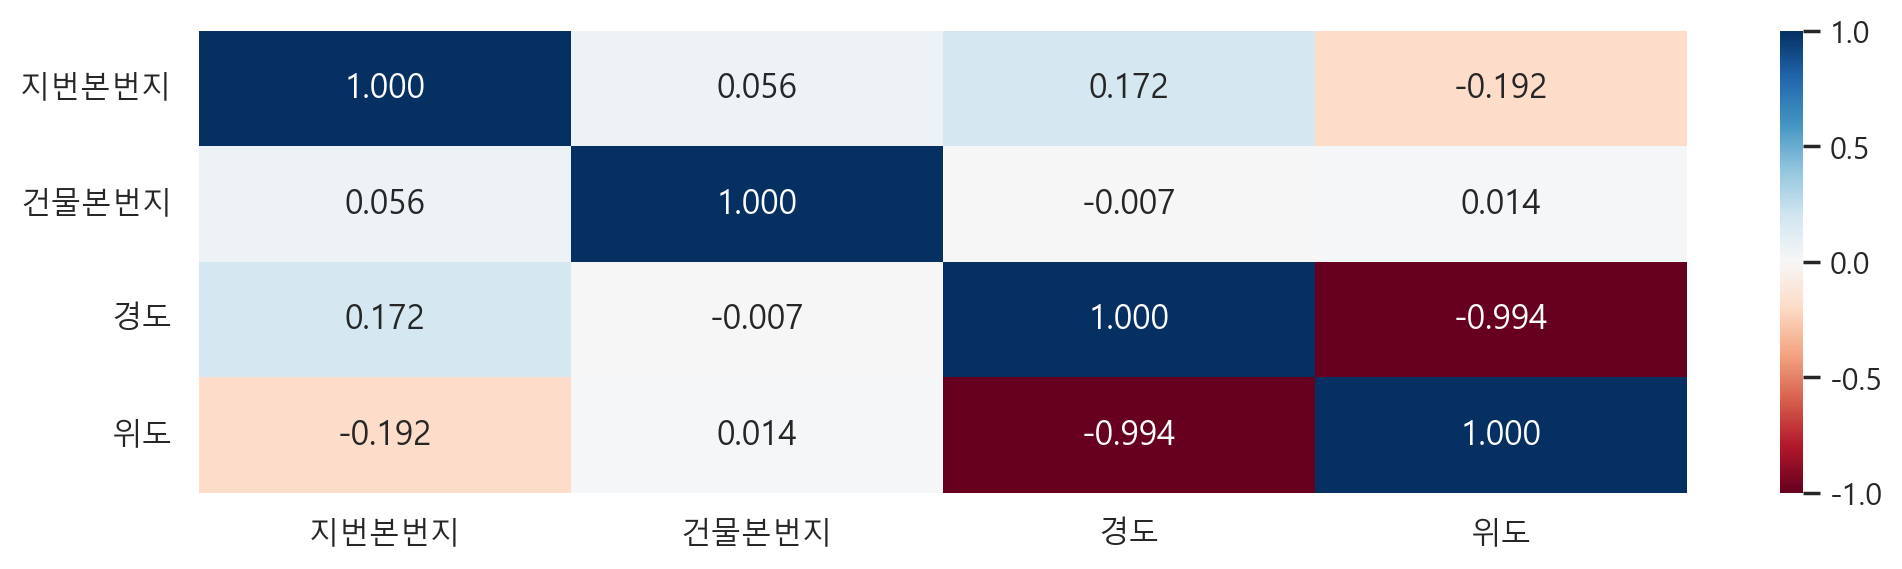

In [241]:
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu', vmin=-1, vmax=1)
plt.show()

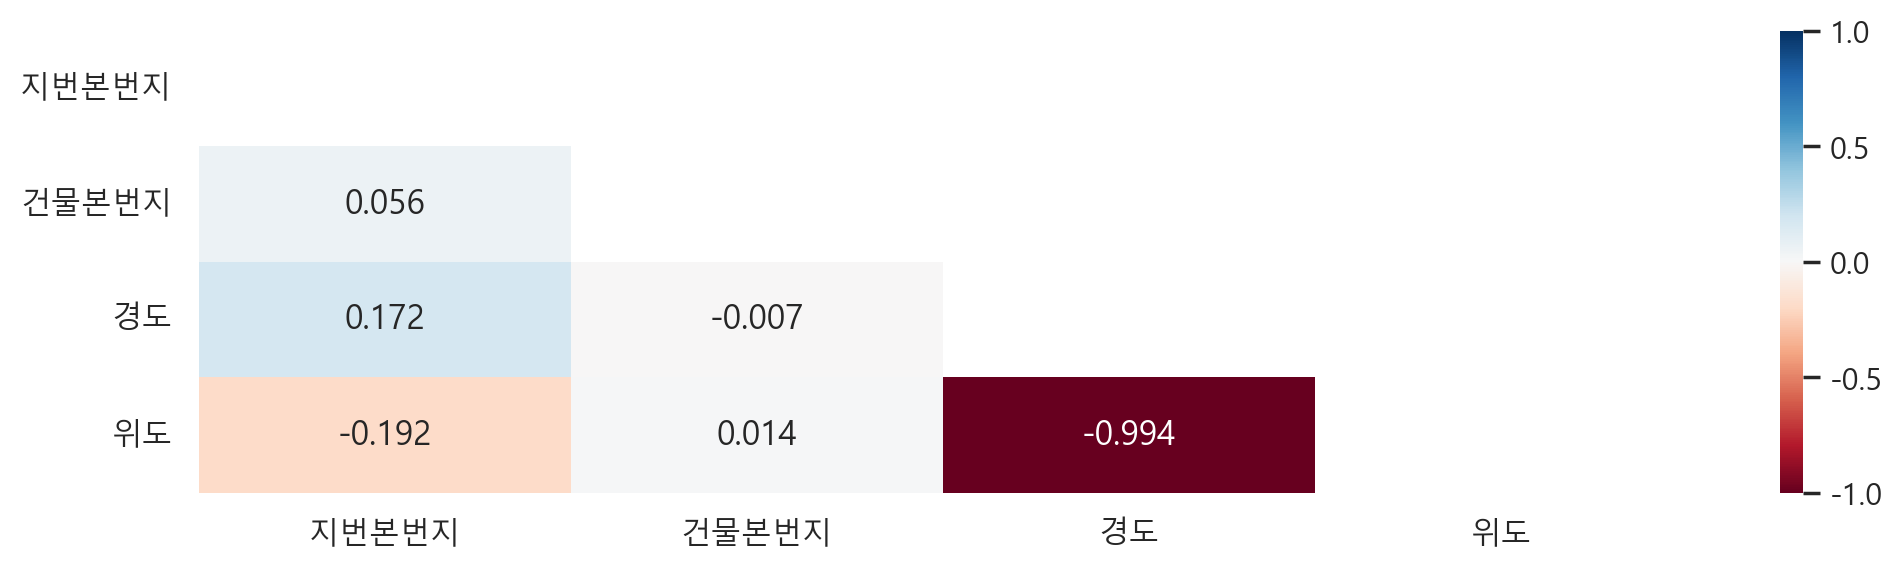

In [248]:
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu', vmin=-1, vmax=1, mask=mask)
plt.show()

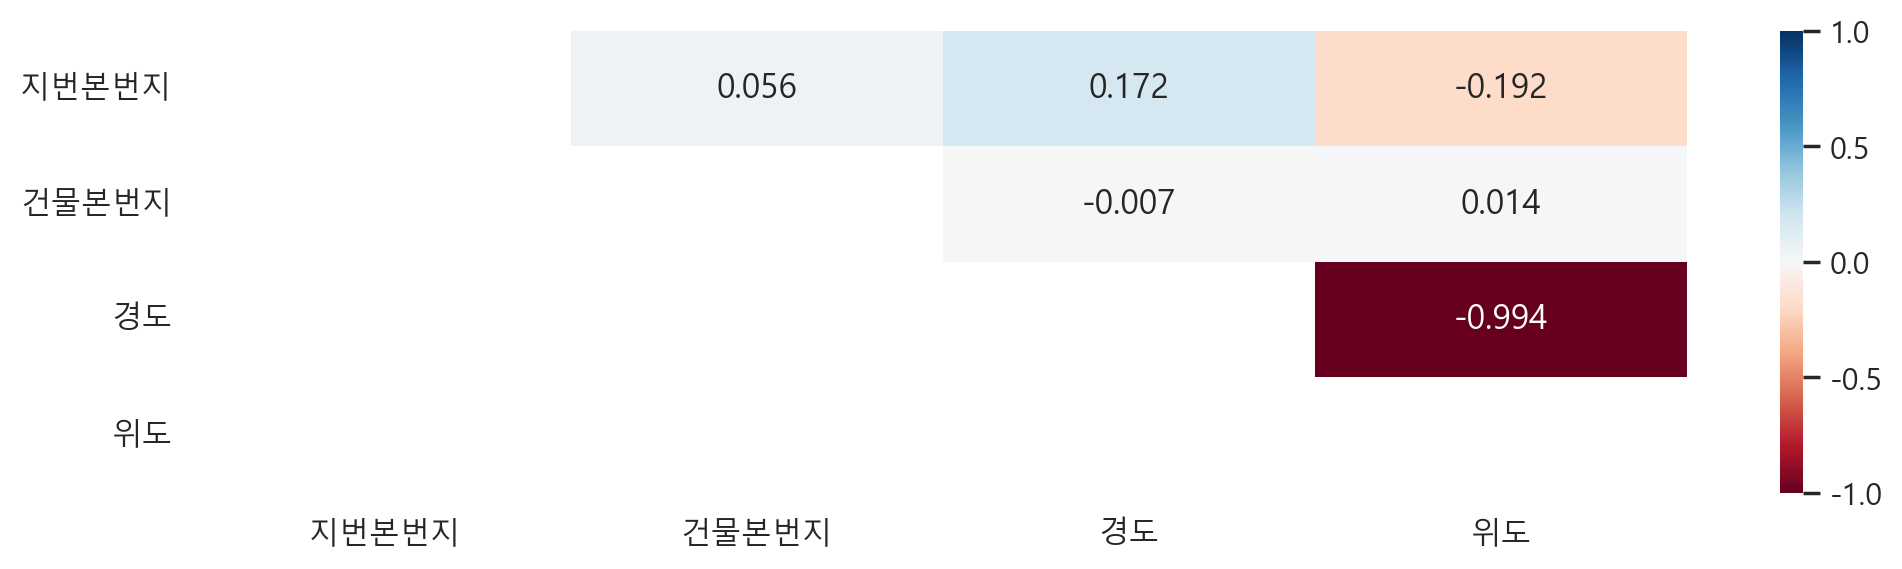

In [249]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu', vmin=-1, vmax=1, mask=~mask)
plt.show()

# 9.	경도와 위도 컬럼을 이용하여 산점도

[Anscombe’s quartet — seaborn 0.10.0 documentation](https://seaborn.pydata.org/examples/anscombes_quartet.html)

## ①	X축에는 경도, y축에는 위도 컬럼을 산점도로 시각화

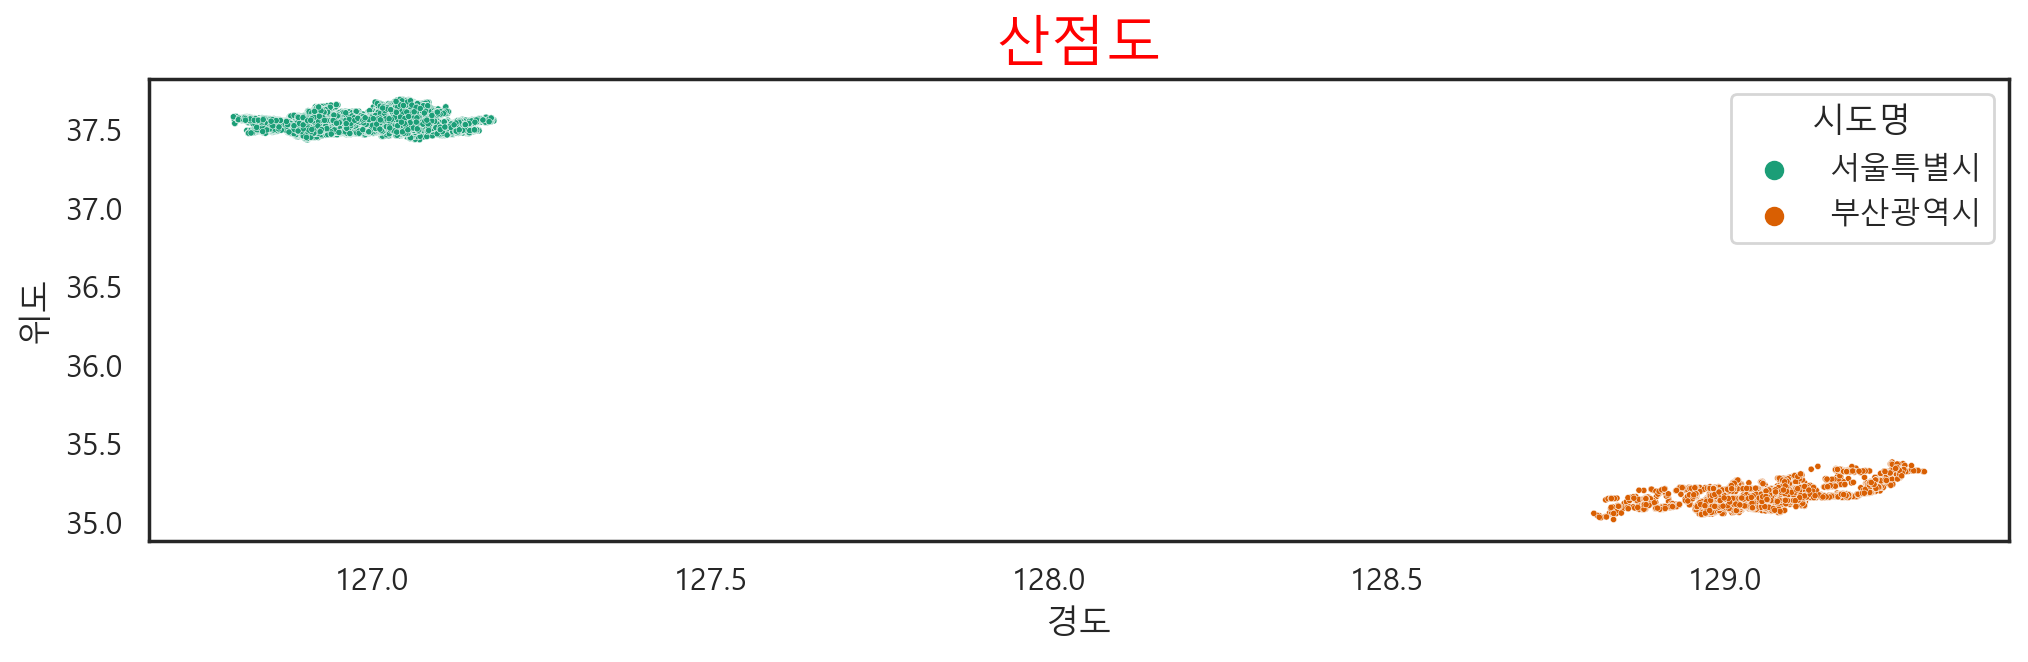

CPU times: total: 1.59 s
Wall time: 1.62 s


In [259]:
%%time
ax = sns.scatterplot(data=df.sample(frac=0.1), x='경도', y='위도', s=5, hue='시도명')
# ax.set_title('산점도', color='r', fontsize=20)
plt.title('산점도', color='r', fontsize=20)
plt.show()

In [250]:
df.shape

(692592, 17)

## ②	경도와 위도의 산점도를 “시도명” 컬럼별로 서브플롯으로 시각화

In [260]:
df['시도명'].unique()

array(['서울특별시', '부산광역시'], dtype=object)

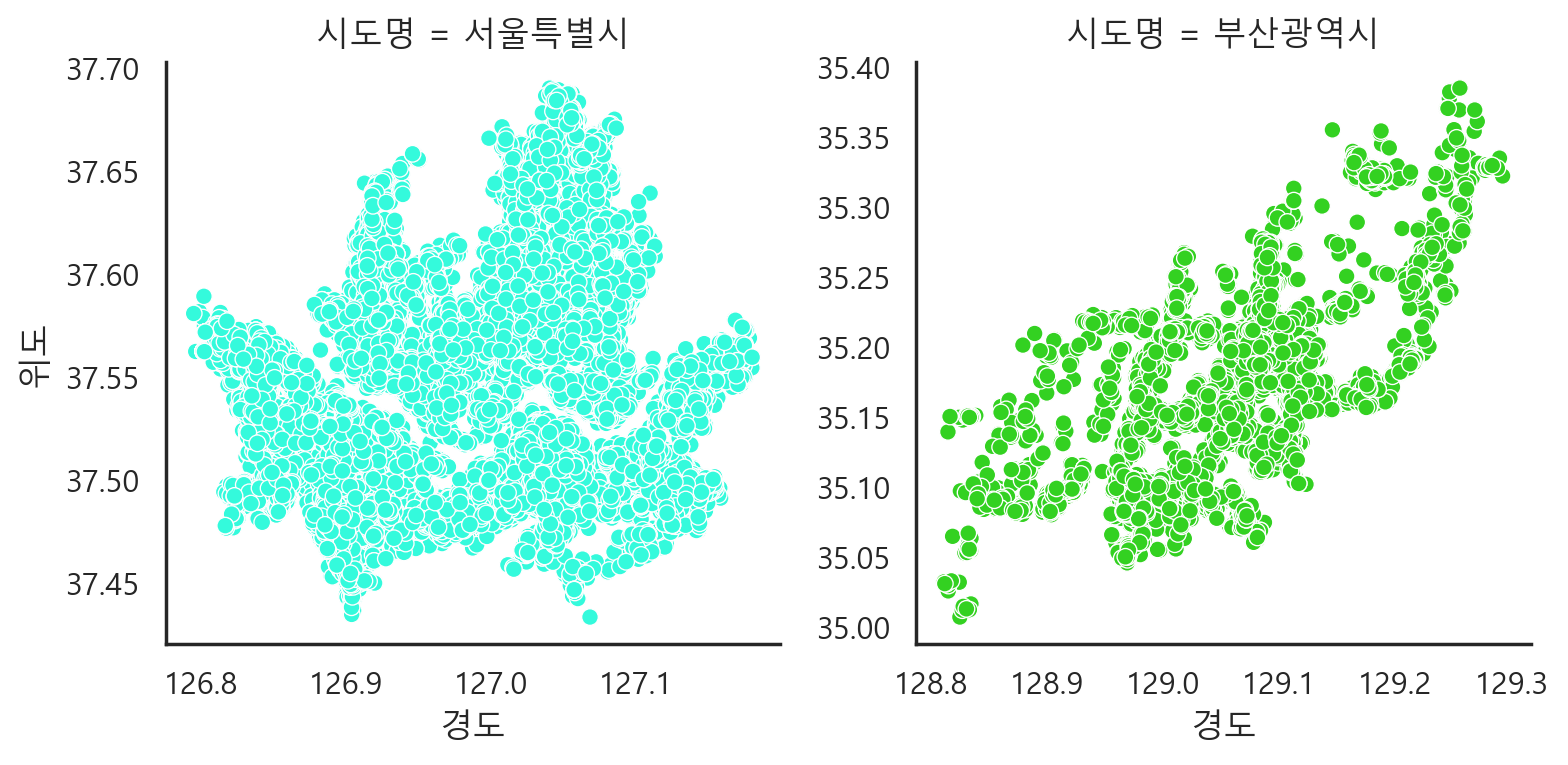

CPU times: total: 2.42 s
Wall time: 2.43 s


In [274]:
%%time
g = sns.relplot(data=df.sample(frac=0.1),
               x='경도', y='위도', 
               hue='시도명', palette=['#33d121','#34fadc'],
               col='시도명',
               # kind='scatter',
               facet_kws={'sharey':False, 'sharex':False},
               height=4, # 높이(인치)
               aspect=1, # 가로세로 비율 
               legend=False, # 범례 안보이게
               col_order=['서울특별시','부산광역시'] # 서브플롯의 순서
               ) 
# g.fig.set_size_inches(10,5)
plt.tight_layout() # 서브플롯의 겹침방지
plt.show()

## ③ 위의 1번에서 시각화된 산점도를 바탕으로 회귀선을 그린다.

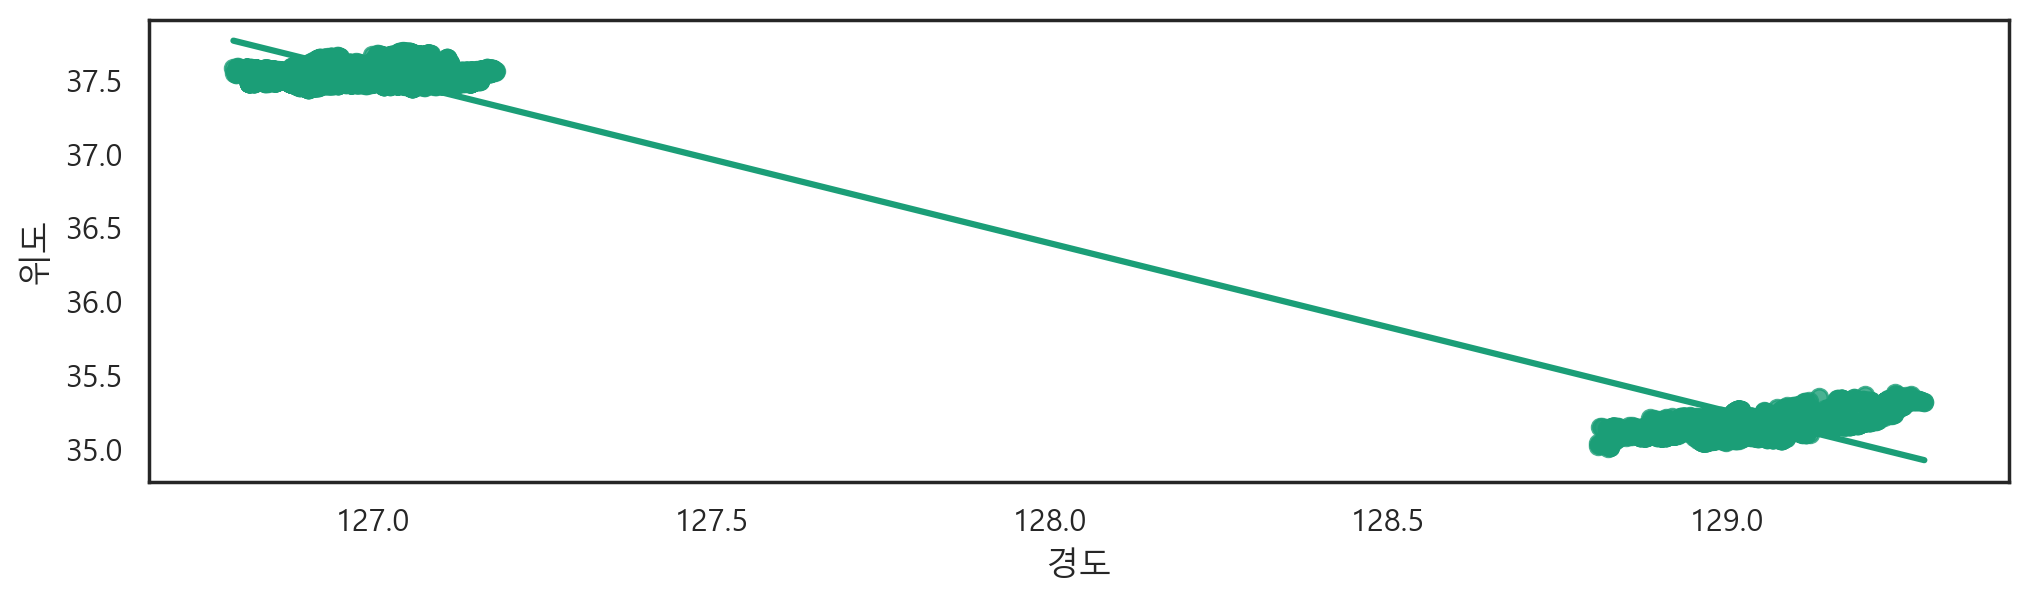

In [281]:
sns.regplot(data=df.sample(frac=0.1), x='경도', y='위도')
plt.show()

## ④ 위의 2번에서 시각화된 산점도를 바탕으로 회귀선을 서브 플롯으로 그린다.

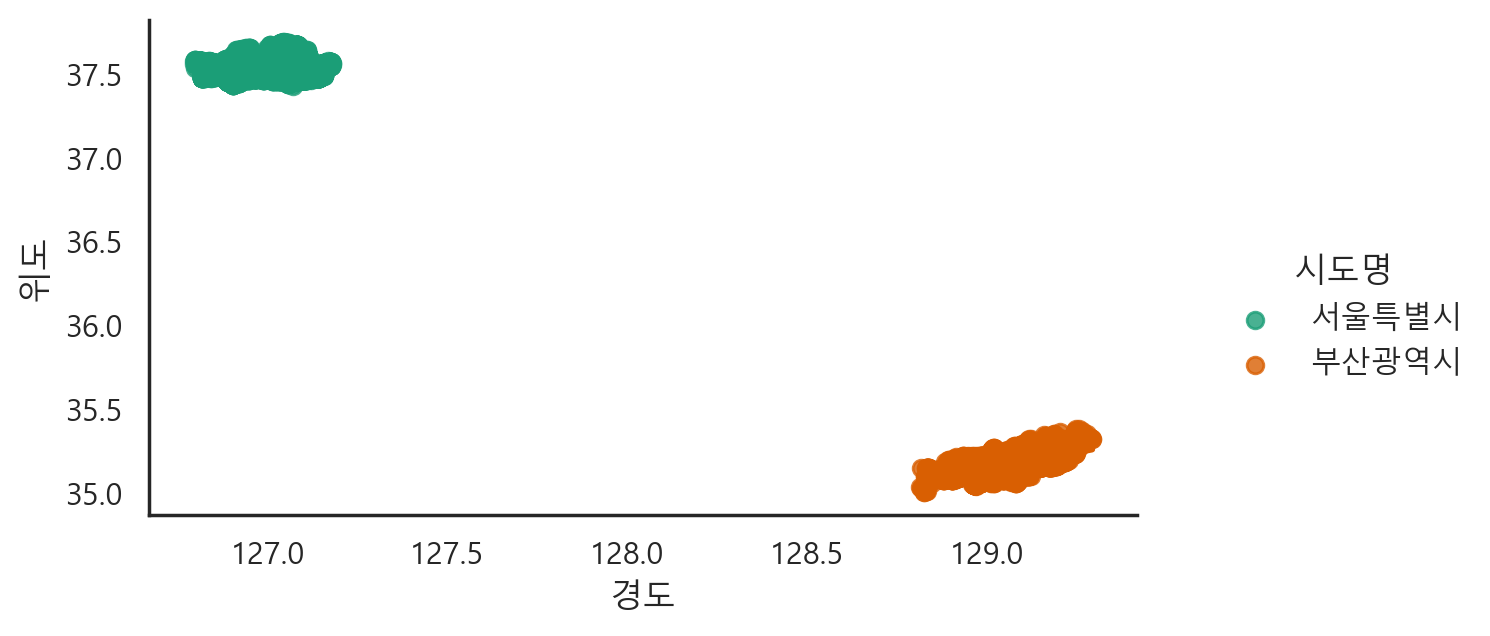

In [286]:
g = sns.lmplot(data=df.sample(frac=0.1), x='경도', y='위도', hue='시도명')
g.fig.set_size_inches(8,3)
plt.show()

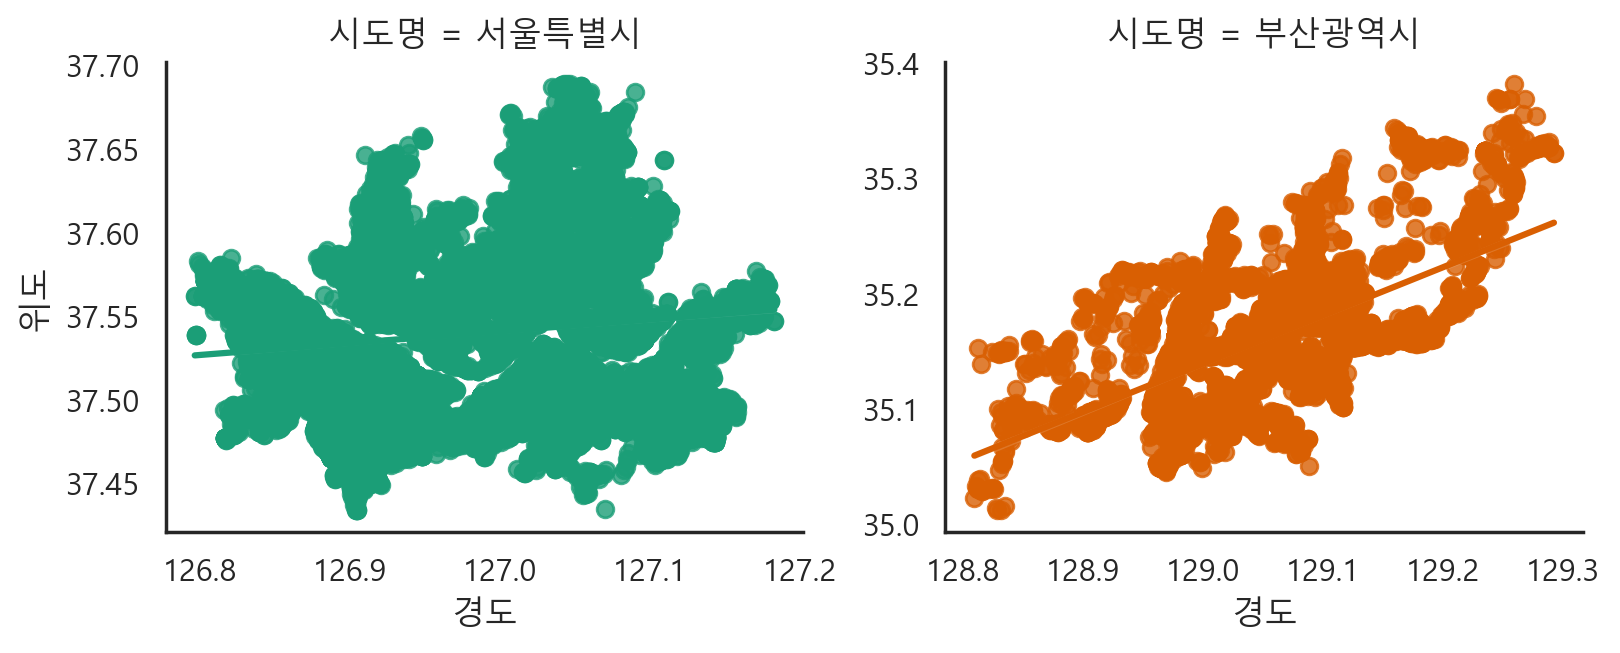

In [288]:
g = sns.lmplot(data=df.sample(frac=0.1), x='경도', y='위도', hue='시도명',
              col='시도명',
              facet_kws={'sharey':False, 'sharex':False})
g.fig.set_size_inches(8,3)
plt.show()

# 10. 상권업종대분류명별 상호명의 개수를 도출하고 시각화하기

# 11. 상권업종대분류명이 음식인 서브셋을 이용한 분석
## ① “상권업종대분류명”이 음식인 서브셋을 변수 df_food에 할당하고 확인


## ②	“상권업종대분류명”이 음식이면서, "시군구명”이 강남구 데이터만 가져와 “상권업종중분류명”별로 빈도수를 구함(loc함수를 이용 vs loc함수 이용안함)

# 12.df 데이터셋에서 “상권업종대분류명”이 음식인 데이터 중 서울특별시 데이터 서브셋
- https://seaborn.pydata.org/tutorial/categorical.html : 범주형그래프
## ①	“상권업종대분류명”이 음식인 서브셋 중 서울특별시 데이터만 변수 df_seoul_food에 할당하고 확인


## ② df_seoul_food 데이터 셋을 시군구명, 상권업종중분류명으로 그룹화하여 상점수를 count한 내용을 food_gu 변수에 할당. 

## ③ df_seoul_food_gu 변수를 표로 출력(df_seoul_food_gu 이용하여 unstack).

## ④ 위 3번 스타일의 표를 pivot_table함수를 이용하여 출력

## ⑤ 3번의 결과 중 강남구 데이터만 뽑아 barplot으로 시각화(판다스 plot이용)

## ⑥ 3번 df_seoul_food_gu를 seaborn을 이용하여 구별 음식점 상호 개수를 시각화

## ⑦ 상권업종중분류명별 음식점 상호갯수

## ⑧	Seaborn의 catplot을 이용하여 상권업종중분류별 음식점을 구별로 시각화(서브플롯으로 시각화)

https://seaborn.pydata.org/tutorial/categorical.html

## ⑨	Seaborn의 catplot을 이용하여 구별 음식점을 상권업종중분류명별로 서브 플롯으로 시각화

# 13.	구별로 학원수 비교 : 서울 대치동이나 목동에 사교육이 발달되었다는 가설을 뒷받침할 수 있는 분석
## ① 서울시 교육(상권업종대분류명 이용) 데이터를 df_academy 변수에 할당하고 확인


## ②	df_academy 데이터 셋을 상호명별로 빈도수 출력(value_counts()함수 이용하거나 groupby이용)

## ③ df_academy 데이터 셋을 상호명별로 빈도수 상위 10개 출력

## ④ df_academy 데이터 셋을 시군구명 별로 빈도수 출력(학원이 가장 많은 구부터 출력)

## ⑤df_academy 데이터 셋에서 어떤 종류의 학원들이 많은지 상위10개만 academy_count변수에 할당하고 출력(상권업종소분류명 컬럼 이용)

## ⑥ df_academy 데이터셋에서 상권업종소분류명별로 빈도수를 구했을 때 빈도가 1000이상인 데이터만 따로 academy_count_1000변수에 할당

## ⑦ df_academy 데이터셋을 “시군구명”, "상권업종소분류명” 별 상호명 빈도수를 academy_group 변수에 할당 출력

## ⑧ academy_group 데이터셋에서 강남구 데이터만 출력 및 시각화(barplot)

## ⑨ df_academy데이터 중 “법정동명”컬럼이 “대치동”과 “목동”인 데이터만 가져와 상권업종소분류명별 빈도수 출력

## ⑩“상권업종소분류명”별 "시군구명” 별 상호명 빈도수를 g변수에 할당하고 출력

## ⑪ g변수의 내용중 "상권업종소분류명” 컬럼이 “입시·교과학원”데이터만 시각화(pandas의 plot.bar, pandas의 barh, seaborn의 barplot)

# 14. 서울시 데이터만 경도와 위도를 산점도로 시각화
## ① df_academy 데이터셋의 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화


https://stackoverflow.com/questions/30490740/move-legend-outside-figure-in-seaborn-tsplot : 범례사용

## ② df_academy 데이터셋의 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

## ③ df_academy 데이터셋 중 “입시·교과학원” 데이터만, 경도와 위도를 “시군구명”별로 색상을 다르게 scatterplot으로 시각화

## ④ df_academy 데이터셋 중 “태권도/무술학원” 데이터만, 경도와 위도를 “시군명”별로 색상을 다르게 scatterplot으로 시각화

## ⑤ df_academy 데이터셋 중 “입시·교과학원” 데이터와 “태권도/무술학원” 데이터만, 경도와 위도를 “상권업종소분류명”별로 색상을 다르게 scatterplot으로 시각화

# 15. 지도시각화 : Folium
` 아나콘다 프롬프트에서 아래의 둘 중 하나를 실행`

`pip install folium`

`conda install -c conda-forge folium`

-	docs : https://python-visualization.github.io/folium/latest/getting_started.html?utm_source=chatgpt.com
-	Quickstart : https://python-visualization.github.io/folium/version-v0.9.1/quickstart.html?utm_source=chatgpt.com


In [ ]:
# 태권도/무술학원과 입시·교과학원을 분리해서 지도 시각화